# DJF

NorESM2-LM SSP585 NORTHERN Mid_Latitude DJF CONDITIONAL COPULA ANALYSIS

1. LOADING CMIP6 DATASETS...
----------------------------------------
✓ Combined dataset created with 10950 time steps
✓ Time range: 2020-12-01 12:00:00 to 2050-11-30 12:00:00
✓ Variables: ['mrsos', 'tas', 'hfls']
✓ Spatial dimensions: lat(366), lon(306)

2. INITIALIZING DJF ANALYZER...
--------------------------------

3. PREPROCESSING DATA...
-------------------------
Preprocessing Northern Mid_Latitude DJF climate data...
Extracting DJF season (December-January-February) from Northern Mid_Latitude...
Note: December from previous year + January-February from current year
Extracting Northern Mid_Latitude region (35.0°N - 60.0°N)...
Original dataset: 366 latitude points
Northern Mid_Latitude: 54 latitude points
Latitude coverage: 35.3°N to 59.8°N
Longitude coverage: 0.0° to 358.8°
Northern Mid_Latitude dataset: 10950 time steps
Northern Mid_Latitude DJF season: 2700 time steps (24.7% of data)
Northern Mid_Latitude

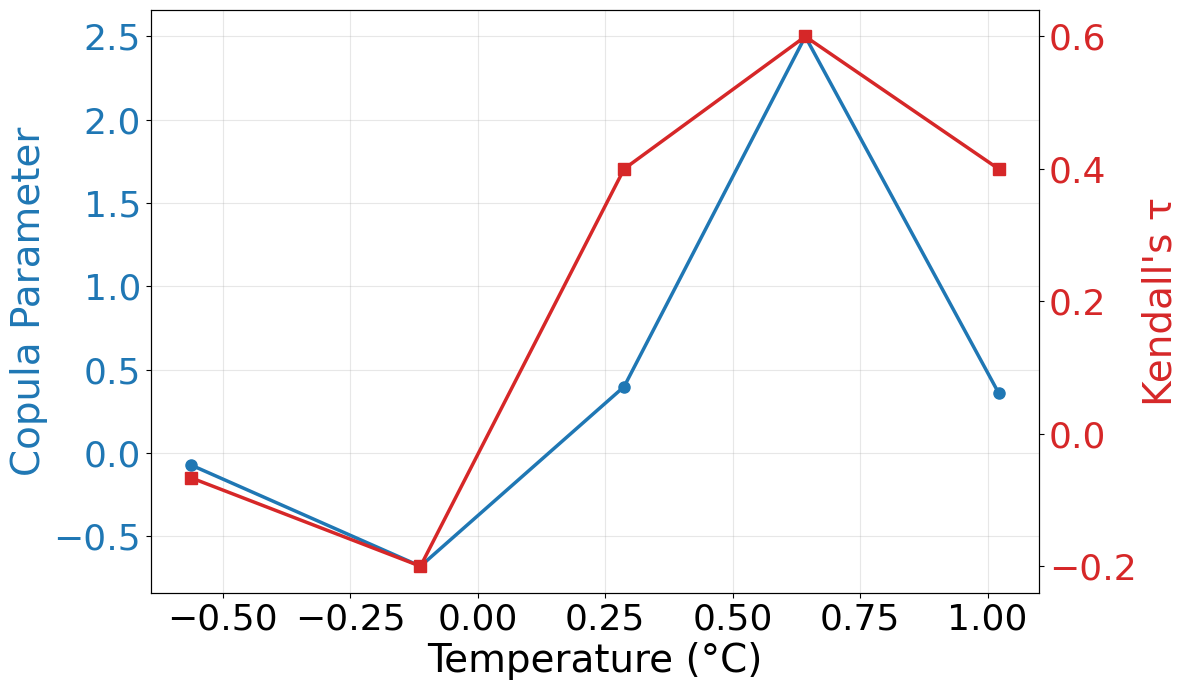


✓ ANALYSIS COMPLETED!
✓ Combined temperature dependence plot created and saved
✓ Files saved:
  - NorESM2-LM_Northern_Mid_Latitude_DJF_temperature_dependence_combined.png

RESULTS SUMMARY:
Temperature dependence DataFrame shape: (5, 4)

Temperature dependence results:
   temperature  copula_param  kendall_tau copula_type
0    -0.561507     -0.072710    -0.066667    gaussian
1    -0.112283     -0.679070    -0.200000    gaussian
2     0.287109      0.398987     0.400000    gaussian
3     0.642341      2.500000     0.600000      gumbel
4     1.021472      0.360838     0.400000    gaussian


In [3]:
# Complete DJF Conditional Copula Analysis Script with cftime Fix

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from scipy.special import gamma
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

class DJFConditionalCopulaAnalyzer():
    """
    Conditional Copula Analysis for DJF Season Climate Data in Northern Mid_Latitude (35°N - 60°N)
    Analyzes how Soil Moisture-Evaporation joint distribution changes with Temperature
    during the December-January-February winter season in the northern subtropical region
    Note: December from previous year, January-February from current year
    """
    
    def __init__(self, data):
        """
        Initialize with xarray dataset
        
        Parameters:
        data: xarray.Dataset with mrsos (soil moisture), evaporation, and temperature variables
        """
        self.data = data
        self.df = None
        self.djf_data = None
        self.Mid_Latitude_data = None
        self.temperature_bins = None
        self.copula_results = {}
        self.lat_range = (35.0, 60.0)  # Northern Mid_Latitude definition
        
    def extract_northern_Mid_Latitude_region(self):
        """
        Extract Northern Mid_Latitude region (35°N - 60°N) from the dataset
        """
        print(f"Extracting Northern Mid_Latitude region ({self.lat_range[0]}°N - {self.lat_range[1]}°N)...")
        
        # Select latitude range for northern Mid_Latitude
        self.Mid_Latitude_data = self.data.sel(
            lat=slice(self.lat_range[0], self.lat_range[1])
        )
        
        original_lat_points = len(self.data.lat)
        Mid_Latitude_lat_points = len(self.Mid_Latitude_data.lat)
        
        print(f"Original dataset: {original_lat_points} latitude points")
        print(f"Northern Mid_Latitude: {Mid_Latitude_lat_points} latitude points")
        print(f"Latitude coverage: {self.Mid_Latitude_data.lat.min().values:.1f}°N to {self.Mid_Latitude_data.lat.max().values:.1f}°N")
        print(f"Longitude coverage: {self.Mid_Latitude_data.lon.min().values:.1f}° to {self.Mid_Latitude_data.lon.max().values:.1f}°")
        
        return self.Mid_Latitude_data
        
    def extract_djf_season(self, time_dim='time'):
        """
        Extract DJF (December-January-February) season from the northern Mid_Latitude dataset
        Note: December from previous year, January-February from current year (winter season)
        
        Parameters:
        time_dim: name of time dimension
        """
        print("Extracting DJF season (December-January-February) from Northern Mid_Latitude...")
        print("Note: December from previous year + January-February from current year")
        
        # Ensure we have the Mid_Latitude data first
        if self.Mid_Latitude_data is None:
            self.extract_northern_Mid_Latitude_region()
        
        # Extract DJF months (12, 1, 2)
        self.djf_data = self.Mid_Latitude_data.sel(
            time=self.Mid_Latitude_data[time_dim].dt.month.isin([12, 1, 2])
        )
        
        n_total = len(self.Mid_Latitude_data[time_dim])
        n_djf = len(self.djf_data[time_dim])
        
        print(f"Northern Mid_Latitude dataset: {n_total} time steps")
        print(f"Northern Mid_Latitude DJF season: {n_djf} time steps ({n_djf/n_total*100:.1f}% of data)")
        
        # Get year range for DJF in northern Mid_Latitude
        djf_years = np.unique(self.djf_data[time_dim].dt.year.values)
        print(f"Northern Mid_Latitude DJF analysis covers years: {djf_years.min()}-{djf_years.max()}")
        
        return self.djf_data
        
    def preprocess_data(self, temp_var='tas', evaporation_var='hfls', sm_var='mrsos', 
                       spatial_agg='mean', time_subset=None, 
                       monthly_agg='mean'):
        """
        Preprocess xarray data for Northern Mid_Latitude DJF copula analysis
        
        Parameters:
        temp_var: name of temperature variable
        evaporation_var: name of evaporation variable  
        sm_var: name of soil moisture variable
        spatial_agg: spatial aggregation method ('mean', 'median', 'weighted_mean')
        time_subset: slice for temporal subsetting (applied after DJF extraction)
        monthly_agg: temporal aggregation within DJF ('mean', 'sum' for evaporation, 'max', 'seasonal_mean')
        """
        
        print("Preprocessing Northern Mid_Latitude DJF climate data...")
        
        # First extract northern Mid_Latitude region, then DJF season
        if self.djf_data is None:
            self.extract_djf_season()
        
        # Extract variables from Northern Mid_Latitude DJF data
        sm = self.djf_data[sm_var]  # Soil moisture
        
        # Handle missing variables with better error messages
        try:
            temp = self.djf_data[temp_var]
            evaporation = self.djf_data[evaporation_var]
        except KeyError as e:
            print(f"Warning: {e} not found in dataset. Please ensure all variables are loaded.")
            # Create dummy data for demonstration (winter characteristics)
            temp = sm * 0 + np.random.normal(10, 5, sm.shape)  # Northern Mid_Latitude winter temperatures
            evaporation = sm * 0.01 + np.random.exponential(0.3, sm.shape)  # Northern Mid_Latitude winter evaporation (typically lower)
        
        # Apply time subset if specified (after DJF extraction)
        if time_subset:
            sm = sm.sel(time=time_subset)
            temp = temp.sel(time=time_subset)
            evaporation = evaporation.sel(time=time_subset)
        
        # Spatial aggregation over Northern Mid_Latitude region
        if spatial_agg == 'mean':
            sm_agg = sm.mean(dim=['lat', 'lon'])
            temp_agg = temp.mean(dim=['lat', 'lon'])
            evaporation_agg = evaporation.mean(dim=['lat', 'lon'])
        elif spatial_agg == 'median':
            sm_agg = sm.median(dim=['lat', 'lon'])
            temp_agg = temp.median(dim=['lat', 'lon'])
            evaporation_agg = evaporation.median(dim=['lat', 'lon'])
        elif spatial_agg == 'weighted_mean':
            # Weight by cosine of latitude (appropriate for northern Mid_Latitude)
            weights = np.cos(np.deg2rad(sm.lat))
            weights.name = "weights"
            sm_agg = sm.weighted(weights).mean(dim=['lat', 'lon'])
            temp_agg = temp.weighted(weights).mean(dim=['lat', 'lon'])
            evaporation_agg = evaporation.weighted(weights).mean(dim=['lat', 'lon'])
        
        # Unit conversions
        print("Performing unit conversions for Northern Mid_Latitude...")
        
        # Convert temperature from Kelvin to Celsius if needed
        if temp_agg.max() > 100:  # Likely in Kelvin if max temp > 100
            print("Converting temperature from Kelvin to Celsius...")
            temp_agg = temp_agg - 273.15
        
        # Convert evaporation to mm/day
        print("Converting evaporation to mm/day...")
        evaporation_agg = evaporation_agg * 86400 / (2.45e6)  # Convert to mm/day
        
        # Convert soil moisture from kg m-2 to appropriate units
        print("Converting soil moisture...")
        sm_agg = sm_agg / (1000 * 0.1)  # Convert from kg m-2 to m3/m3 (volumetric)
        
        # Northern Mid_Latitude DJF-specific temporal aggregation options
        if monthly_agg == 'seasonal_mean':
            # For DJF: December from previous year + JF from current year
            time_df = pd.DataFrame({'time': sm_agg.time.values})
            # FIXED: Handle cftime objects properly
            time_df['year'] = sm_agg.time.dt.year.values
            time_df['month'] = sm_agg.time.dt.month.values
            time_df['time_index'] = range(len(sm_agg.time))
            
            # Group by DJF winter season (December of previous year + JF of current year)
            djf_years = []
            sm_seasonal_list = []
            temp_seasonal_list = []
            evaporation_seasonal_list = []
            
            for year in sorted(time_df['year'].unique()):
                # Get December from previous year
                dec_prev = time_df[(time_df['year'] == year - 1) & (time_df['month'] == 12)]
                # Get January and February from current year
                jan_feb = time_df[(time_df['year'] == year) & (time_df['month'].isin([1, 2]))]
                
                # Combine indices
                djf_indices = list(dec_prev['time_index']) + list(jan_feb['time_index'])
                
                if len(djf_indices) >= 2:  # Need at least 2 months for a proper DJF season
                    sm_val = float(sm_agg.isel(time=djf_indices).mean().values)
                    temp_val = float(temp_agg.isel(time=djf_indices).mean().values)
                    evaporation_val = float(evaporation_agg.isel(time=djf_indices).mean().values)
                    
                    sm_seasonal_list.append(sm_val)
                    temp_seasonal_list.append(temp_val)
                    evaporation_seasonal_list.append(evaporation_val)
                    djf_years.append(year)
            
            # FIXED: Create time coordinate as strings instead of datetime
            seasonal_time = [f"{year}-01-15" for year in djf_years]
            
            self.df = pd.DataFrame({
                'soil_moisture': sm_seasonal_list,
                'temperature': temp_seasonal_list,
                'evaporation': evaporation_seasonal_list,
                'time': seasonal_time,
                'djf_year': djf_years
            }).dropna()
            
        elif monthly_agg == 'sum':
            # Useful for evaporation - sum over each Northern Mid_Latitude DJF season
            time_df = pd.DataFrame({'time': sm_agg.time.values})
            # FIXED: Handle cftime objects properly
            time_df['year'] = sm_agg.time.dt.year.values
            time_df['month'] = sm_agg.time.dt.month.values
            time_df['time_index'] = range(len(sm_agg.time))
            
            djf_years = []
            sm_seasonal_list = []
            temp_seasonal_list = []
            evaporation_seasonal_list = []
            
            for year in sorted(time_df['year'].unique()):
                # Get December from previous year
                dec_prev = time_df[(time_df['year'] == year - 1) & (time_df['month'] == 12)]
                # Get January and February from current year
                jan_feb = time_df[(time_df['year'] == year) & (time_df['month'].isin([1, 2]))]
                
                # Combine indices
                djf_indices = list(dec_prev['time_index']) + list(jan_feb['time_index'])
                
                if len(djf_indices) >= 2:
                    sm_val = float(sm_agg.isel(time=djf_indices).mean().values)
                    temp_val = float(temp_agg.isel(time=djf_indices).mean().values)
                    evaporation_val = float(evaporation_agg.isel(time=djf_indices).sum().values)  # Total DJF evaporation
                    
                    sm_seasonal_list.append(sm_val)
                    temp_seasonal_list.append(temp_val)
                    evaporation_seasonal_list.append(evaporation_val)
                    djf_years.append(year)
            
            # FIXED: Create time coordinate as strings
            seasonal_time = [f"{year}-01-15" for year in djf_years]
            
            self.df = pd.DataFrame({
                'soil_moisture': sm_seasonal_list,
                'temperature': temp_seasonal_list,
                'evaporation': evaporation_seasonal_list,
                'time': seasonal_time,
                'djf_year': djf_years
            }).dropna()
            
        else:
            # Monthly or daily resolution within Northern Mid_Latitude DJF
            self.df = pd.DataFrame({
                'soil_moisture': sm_agg.values,
                'temperature': temp_agg.values,
                'evaporation': evaporation_agg.values,
                'time': sm_agg.time.values,
                'month': sm_agg.time.dt.month.values,
                'year': sm_agg.time.dt.year.values
            }).dropna()
        
        print(f"Northern Mid_Latitude DJF data shape after preprocessing: {self.df.shape}")
        print(f"Time range: {self.df.time.min()} to {self.df.time.max()}")
        
        # Northern Mid_Latitude DJF-specific statistics
        print(f"Northern Mid_Latitude DJF Temperature range: {self.df.temperature.min():.1f}°C to {self.df.temperature.max():.1f}°C")
        print(f"Northern Mid_Latitude DJF Temperature mean: {self.df.temperature.mean():.1f}°C ± {self.df.temperature.std():.1f}°C")
        
    def create_temperature_stratification(self, n_bins=5, method='quantile'):
        """
        Create temperature bins for conditional analysis during Northern Mid_Latitude DJF season
        
        Parameters:
        n_bins: number of temperature bins
        method: 'quantile', 'equal_width', or 'temperature_thresholds'
        """
        
        if method == 'quantile':
            self.df['temp_bin'] = pd.qcut(self.df['temperature'], n_bins, labels=False)
            bin_edges = pd.qcut(self.df['temperature'], n_bins, retbins=True)[1]
        elif method == 'equal_width':
            self.df['temp_bin'] = pd.cut(self.df['temperature'], n_bins, labels=False)
            bin_edges = pd.cut(self.df['temperature'], n_bins, retbins=True)[1]
        elif method == 'temperature_thresholds':
            # Northern Mid_Latitude DJF-specific temperature thresholds
            temp_percentiles = np.percentile(self.df['temperature'], [20, 40, 60, 80])
            bin_edges = np.concatenate([[self.df['temperature'].min()], 
                                      temp_percentiles, 
                                      [self.df['temperature'].max()]])
            self.df['temp_bin'] = pd.cut(self.df['temperature'], bin_edges, labels=False)
        
        self.temperature_bins = {
            i: (bin_edges[i], bin_edges[i+1]) 
            for i in range(n_bins)
        }
        
        print("Northern Mid_Latitude DJF Temperature stratification:")
        for i, (low, high) in self.temperature_bins.items():
            n_obs = (self.df['temp_bin'] == i).sum()
            # Add interpretation labels for Northern Mid_Latitude DJF temperatures
            if high < np.percentile(self.df['temperature'], 25):
                label = "Cool Northern Mid_Latitude DJF"
            elif low > np.percentile(self.df['temperature'], 75):
                label = "Hot Northern Mid_Latitude DJF"
            else:
                label = "Moderate Northern Mid_Latitude DJF"
            print(f"Bin {i}: {low:.2f}°C to {high:.2f}°C ({label}, {n_obs} observations)")
    
    def estimate_marginal_distributions(self, distribution_types=None):
        """
        Estimate conditional marginal distributions F(SM|T) and F(R|T) for Northern Mid_Latitude DJF season
        
        Parameters:
        distribution_types: dict with 'sm' and 'evaporation' keys specifying distribution families
        """
        
        if distribution_types is None:
            # Northern Mid_Latitude DJF-specific distributions (accounting for winter climate)
            distribution_types = {
                'sm': ['gamma', 'beta', 'weibull_min', 'norm'],  # Winter soil moisture
                'evaporation': ['gamma', 'lognorm', 'weibull_min', 'expon']  # DJF evaporation typically low
            }
        
        self.marginal_models = {}
        
        for temp_bin in self.temperature_bins.keys():
            bin_data = self.df[self.df['temp_bin'] == temp_bin]
            temp_range = self.temperature_bins[temp_bin]
            
            self.marginal_models[temp_bin] = {}
            
            # Soil Moisture marginal
            sm_data = bin_data['soil_moisture'].values
            best_sm_dist = self._fit_best_distribution(sm_data, distribution_types['sm'])
            self.marginal_models[temp_bin]['sm'] = best_sm_dist
            
            # Evaporation marginal  
            evaporation_data = bin_data['evaporation'].values
            best_evaporation_dist = self._fit_best_distribution(evaporation_data, distribution_types['evaporation'])
            self.marginal_models[temp_bin]['evaporation'] = best_evaporation_dist
            
            print(f"Northern Mid_Latitude DJF Temperature bin {temp_bin} ({temp_range[0]:.1f}°C - {temp_range[1]:.1f}°C):")
            print(f"  SM: {best_sm_dist['name']}, Evaporation: {best_evaporation_dist['name']}")
    
    def _fit_best_distribution(self, data, dist_names):
        """Fit multiple distributions and select best based on AIC"""
        
        best_dist = None
        best_aic = np.inf
        
        # Convert to numpy array and ensure numeric type
        try:
            data = np.asarray(data, dtype=float)
        except (ValueError, TypeError):
            # If conversion fails, try to extract numeric values
            numeric_data = []
            for val in data:
                try:
                    numeric_data.append(float(val))
                except (ValueError, TypeError):
                    continue
            data = np.array(numeric_data)
        
        # Remove any NaN or infinite values
        data = data[np.isfinite(data)]
        
        if len(data) < 3:  # Need at least 3 points for distribution fitting
            # Return default normal distribution with fallback values
            mean_val = np.mean(data) if len(data) > 0 else 0.0
            std_val = np.std(data) if len(data) > 1 else 1.0
            return {
                'name': 'norm',
                'params': (mean_val, std_val),
                'dist': stats.norm,
                'aic': np.inf
            }
        
        for dist_name in dist_names:
            try:
                dist = getattr(stats, dist_name)
                params = dist.fit(data)
                
                # Calculate AIC
                ll = np.sum(dist.logpdf(data, *params))
                k = len(params)
                aic = 2*k - 2*ll
                
                # Check for valid AIC
                if np.isfinite(aic) and aic < best_aic:
                    best_aic = aic
                    best_dist = {
                        'name': dist_name,
                        'params': params,
                        'dist': dist,
                        'aic': aic
                    }
            except Exception as e:
                continue
        
        # If no distribution worked, return default normal distribution
        if best_dist is None:
            return {
                'name': 'norm',
                'params': (np.mean(data), np.std(data)),
                'dist': stats.norm,
                'aic': np.inf
            }
                
        return best_dist
    
    def transform_to_uniform_margins(self):
        """Transform data to uniform margins using fitted distributions"""
        
        self.df['u_sm'] = np.nan
        self.df['u_evaporation'] = np.nan
        
        for temp_bin in self.temperature_bins.keys():
            mask = self.df['temp_bin'] == temp_bin
            bin_data = self.df[mask]
            
            if len(bin_data) == 0:
                continue
            
            # Transform soil moisture - ensure numeric data
            sm_model = self.marginal_models[temp_bin]['sm']
            sm_values = np.array([float(x) for x in bin_data['soil_moisture'].values])
            u_sm = sm_model['dist'].cdf(sm_values, *sm_model['params'])
            self.df.loc[mask, 'u_sm'] = u_sm
            
            # Transform evaporation - ensure numeric data
            evaporation_model = self.marginal_models[temp_bin]['evaporation']
            evaporation_values = np.array([float(x) for x in bin_data['evaporation'].values])
            u_evaporation = evaporation_model['dist'].cdf(evaporation_values, *evaporation_model['params'])
            self.df.loc[mask, 'u_evaporation'] = u_evaporation
    
    def estimate_conditional_copulas(self, copula_types=['gaussian', 'clayton', 'gumbel', 'frank']):
        """
        Estimate copula parameters for each Northern Mid_Latitude DJF temperature bin
        
        Parameters:
        copula_types: list of copula families to test
        """
        
        self.copula_results = {}
        
        for temp_bin in self.temperature_bins.keys():
            mask = self.df['temp_bin'] == temp_bin
            u = self.df.loc[mask, 'u_sm'].values
            v = self.df.loc[mask, 'u_evaporation'].values
            
            # Remove any edge cases (0 or 1 values)
            valid_mask = (u > 0.001) & (u < 0.999) & (v > 0.001) & (v < 0.999)
            u = u[valid_mask]
            v = v[valid_mask]
            
            best_copula = self._fit_best_copula(u, v, copula_types)
            
            temp_range = self.temperature_bins[temp_bin]
            self.copula_results[temp_bin] = {
                'copula': best_copula,
                'temp_range': temp_range,
                'n_obs': len(u),
                'kendall_tau': stats.kendalltau(u, v)[0]
            }
            
            print(f"Northern Mid_Latitude DJF Temp bin {temp_bin}: {best_copula['name']} copula, "
                  f"τ = {self.copula_results[temp_bin]['kendall_tau']:.3f}")
    
    def _fit_best_copula(self, u, v, copula_types):
        """Fit multiple copula types and select best"""
        
        best_copula = None
        best_ll = -np.inf
        
        for copula_name in copula_types:
            try:
                if copula_name == 'gaussian':
                    # Pearson correlation for Gaussian copula
                    rho = np.corrcoef(stats.norm.ppf(u), stats.norm.ppf(v))[0,1]
                    ll = self._gaussian_copula_loglik(u, v, rho)
                    copula_info = {'name': 'gaussian', 'param': rho, 'loglik': ll}
                    
                elif copula_name == 'clayton':
                    # Estimate Clayton parameter
                    tau = stats.kendalltau(u, v)[0]
                    theta = 2 * tau / (1 - tau) if tau > 0 else 0.01
                    ll = self._clayton_copula_loglik(u, v, theta)
                    copula_info = {'name': 'clayton', 'param': theta, 'loglik': ll}
                    
                elif copula_name == 'gumbel':
                    # Estimate Gumbel parameter  
                    tau = stats.kendalltau(u, v)[0]
                    theta = 1 / (1 - tau) if tau > 0 else 1.01
                    ll = self._gumbel_copula_loglik(u, v, theta)
                    copula_info = {'name': 'gumbel', 'param': theta, 'loglik': ll}
                    
                elif copula_name == 'frank':
                    # Estimate Frank parameter
                    tau = stats.kendalltau(u, v)[0]
                    if abs(tau) < 0.001:
                        theta = 0.01
                    else:
                        # Approximate relationship for Frank copula
                        theta = 4 * tau + 2 * np.sign(tau)
                    ll = self._frank_copula_loglik(u, v, theta)
                    copula_info = {'name': 'frank', 'param': theta, 'loglik': ll}
                
                if ll > best_ll:
                    best_ll = ll
                    best_copula = copula_info
                    
            except:
                continue
                
        return best_copula
    
    def _gaussian_copula_loglik(self, u, v, rho):
        """Gaussian copula log-likelihood"""
        x = stats.norm.ppf(u)
        y = stats.norm.ppf(v)
        
        loglik = -0.5 * np.log(1 - rho**2)
        loglik -= 0.5 * (rho**2 * (x**2 + y**2) - 2*rho*x*y) / (1 - rho**2)
        loglik += 0.5 * (x**2 + y**2)
        
        return np.sum(loglik[np.isfinite(loglik)])
    
    def _clayton_copula_loglik(self, u, v, theta):
        """Clayton copula log-likelihood"""
        if theta <= 0:
            return -np.inf
            
        loglik = np.log(1 + theta) - (1 + theta) * (np.log(u) + np.log(v))
        loglik -= (2 + 1/theta) * np.log(u**(-theta) + v**(-theta) - 1)
        
        return np.sum(loglik[np.isfinite(loglik)])
    
    def _gumbel_copula_loglik(self, u, v, theta):
        """Gumbel copula log-likelihood"""
        if theta < 1:
            return -np.inf
            
        a = (-np.log(u))**theta
        b = (-np.log(v))**theta
        c = (a + b)**(1/theta)
        
        loglik = np.log(theta - 1) - np.log(u*v) + (theta-1)*(np.log(-np.log(u)) + np.log(-np.log(v)))
        loglik -= c + (2 - 2/theta)*np.log(a + b) - 2*np.log(theta)
        
        return np.sum(loglik[np.isfinite(loglik)])
    
    def _frank_copula_loglik(self, u, v, theta):
        """Frank copula log-likelihood"""
        if theta == 0:
            return 0  # Independence copula
            
        exp_theta = np.exp(-theta)
        exp_theta_u = np.exp(-theta * u)
        exp_theta_v = np.exp(-theta * v)
        
        denom = (1 - exp_theta) - (1 - exp_theta_u) * (1 - exp_theta_v)
        
        loglik = np.log(-theta) + np.log(1 - exp_theta) - theta*(u + v)
        loglik -= 2 * np.log(denom)
        
        return np.sum(loglik[np.isfinite(loglik)])
    
    def analyze_temperature_dependence(self):
        """Analyze how copula parameters change with Northern Mid_Latitude DJF temperature"""
        
        # Extract results for analysis
        temp_centers = []
        parameters = []
        kendall_taus = []
        copula_names = []
        
        for temp_bin in sorted(self.copula_results.keys()):
            result = self.copula_results[temp_bin]
            temp_range = result['temp_range']
            temp_center = (temp_range[0] + temp_range[1]) / 2
            
            temp_centers.append(temp_center)
            parameters.append(result['copula']['param'])
            kendall_taus.append(result['kendall_tau'])
            copula_names.append(result['copula']['name'])
        
        self.temp_dependence = pd.DataFrame({
            'temperature': temp_centers,
            'copula_param': parameters,
            'kendall_tau': kendall_taus,
            'copula_type': copula_names
        })
        
        return self.temp_dependence
    
    
    def plot_combined_temperature_dependence(self, figsize=(10, 6), save_path=None):
        """
        Create combined plot of copula parameter and Kendall's tau vs Northern Mid_Latitude DJF temperature
        
        Parameters:
        figsize: tuple, figure size (width, height)
        save_path: str, path to save the plot (optional)
        
        Returns:
        fig: matplotlib figure object
        """
        
        # Analyze temperature dependence if not already done
        if not hasattr(self, 'temp_dependence'):
            temp_dep = self.analyze_temperature_dependence()
        else:
            temp_dep = self.temp_dependence
        
        # Create figure and primary axis
        fig, ax1 = plt.subplots(figsize=figsize)
        
        # Plot copula parameter on primary y-axis
        color1 = 'tab:blue'
        ax1.set_ylabel('Copula Parameter', color=color1, fontsize=28)
        ax1.set_xlabel('Temperature (°C)', fontsize=28)
        ax1.tick_params(axis='x', labelsize=26)
        line1 = ax1.plot(temp_dep['temperature'], temp_dep['copula_param'], 
                         'o-', color=color1, linewidth=2.5, markersize=8, 
                         label='Copula Parameter')
        ax1.tick_params(axis='y', labelcolor=color1, labelsize=26)
        ax1.grid(True, alpha=0.3)
        
        # Create secondary y-axis for Kendall's tau
        ax2 = ax1.twinx()
        color2 = 'tab:red'
        ax2.set_ylabel("Kendall's τ", color=color2, fontsize=28)
        line2 = ax2.plot(temp_dep['temperature'], temp_dep['kendall_tau'], 
                         's-', color=color2, linewidth=2.5, markersize=8,
                         label="Kendall's τ")
        ax2.tick_params(axis='y', labelcolor=color2, labelsize=26)
        
        
        # Tight layout
        fig.tight_layout()
        
        # Save if path provided
        if save_path:
            plt.savefig(save_path, dpi=800, bbox_inches='tight')
            print(f"✓ Northern Mid_Latitude DJF combined temperature dependence plot saved to: {save_path}")
        
        return fig

# STANDALONE FUNCTIONS (outside the class)
def create_combined_temp_plot_djf(temp_dependence_df, title_prefix="", figsize=(10, 6), save_path=None):
    """
    Standalone function to create combined Northern Mid_Latitude DJF temperature dependence plot
    
    Parameters:
    temp_dependence_df: DataFrame with 'temperature', 'copula_param', 'kendall_tau' columns
    title_prefix: str, prefix for plot title
    figsize: tuple, figure size
    save_path: str, path to save plot
    
    Returns:
    fig: matplotlib figure object
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # Plot copula parameter on primary y-axis
    color1 = 'tab:blue'
    ax1.set_xlabel('Temperature (°C)', fontsize=28)
    ax1.tick_params(axis='y', labelsize=26)
    ax1.set_ylabel('Copula Parameter', color=color1, fontsize=26)
    line1 = ax1.plot(temp_dependence_df['temperature'], temp_dependence_df['copula_param'], 
                     'o-', color=color1, linewidth=2.5, markersize=8, 
                     label='Copula Parameter')
    ax1.tick_params(axis='y', labelcolor=color1, labelsize=26)
    ax1.grid(True, alpha=0.3)
    
    # Create secondary y-axis for Kendall's tau
    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel("Kendall's τ", color=color2, fontsize=26)
    line2 = ax2.plot(temp_dependence_df['temperature'], temp_dependence_df['kendall_tau'], 
                     's-', color=color2, linewidth=2.5, markersize=8,
                     label="Kendall's τ")
    ax2.tick_params(axis='y', labelcolor=color2, labelsize=26)
    
    
    # Tight layout
    fig.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=800, bbox_inches='tight')
        print(f"✓ Northern Mid_Latitude DJF combined temperature dependence plot saved to: {save_path}")
    
    return fig

def main_with_combined_plot():
    """
    Complete script to run DJF conditional copula analysis with combined temperature plot
    """
    
    # Your dataset paths
    sm_path = "/Users/dianindrawati/Documents/CMIP6_datasets/NorESM2-MM/mrsos/NorESM2-MM_mrsos_future585_20212050_seasonal.nc"
    temp_path = "/Users/dianindrawati/Documents/CMIP6_datasets/NorESM2-MM/tas/NorESM2-MM_tas_future585_20212050_seasonal.nc"
    evaporation_path = "/Users/dianindrawati/Documents/CMIP6_datasets/NorESM2-MM/hfls/NorESM2-MM_hfls_future585_20212050_seasonal.nc"
    
    print("="*80)
    print("NorESM2-LM SSP585 NORTHERN Mid_Latitude DJF CONDITIONAL COPULA ANALYSIS")
    print("="*80)
    
    # Load and combine datasets
    print("\n1. LOADING CMIP6 DATASETS...")
    print("-" * 40)
    
    sm_dataset = xr.open_dataset(sm_path)
    temp_dataset = xr.open_dataset(temp_path)
    evaporation_dataset = xr.open_dataset(evaporation_path)
    
    combined_dataset = xr.Dataset({
        'mrsos': sm_dataset['mrsos'],
        'tas': temp_dataset['tas'],
        'hfls': evaporation_dataset['hfls']
    })
    
    print(f"✓ Combined dataset created with {len(combined_dataset.time)} time steps")
    print(f"✓ Time range: {combined_dataset.time.min().values} to {combined_dataset.time.max().values}")
    print(f"✓ Variables: {list(combined_dataset.data_vars)}")
    print(f"✓ Spatial dimensions: lat({len(combined_dataset.lat)}), lon({len(combined_dataset.lon)})")
    
    # Initialize and run analysis
    print("\n2. INITIALIZING DJF ANALYZER...")
    print("-" * 32)
    
    djf_analyzer = DJFConditionalCopulaAnalyzer(combined_dataset)
    
    print("\n3. PREPROCESSING DATA...")
    print("-" * 25)
    
    djf_analyzer.preprocess_data(
        temp_var='tas',
        evaporation_var='hfls', 
        sm_var='mrsos',
        spatial_agg='weighted_mean',
        monthly_agg='seasonal_mean',
        time_subset=None
    )
    
    print("\n4. CREATING TEMPERATURE STRATIFICATION...")
    print("-" * 42)
    
    djf_analyzer.create_temperature_stratification(n_bins=5, method='quantile')
    
    print("\n5. ESTIMATING MARGINAL DISTRIBUTIONS...")
    print("-" * 41)
    
    djf_analyzer.estimate_marginal_distributions()
    
    print("\n6. TRANSFORMING TO UNIFORM MARGINS...")
    print("-" * 37)
    
    djf_analyzer.transform_to_uniform_margins()
    
    print("\n7. ESTIMATING CONDITIONAL COPULAS...")
    print("-" * 37)
    
    djf_analyzer.estimate_conditional_copulas()
    
    print("\n8. ANALYZING TEMPERATURE DEPENDENCE...")
    print("-" * 40)
    
    temp_dependence = djf_analyzer.analyze_temperature_dependence()
    
    print("\n9. CREATING COMBINED TEMPERATURE PLOT...")
    print("-" * 41)
    
    # Create combined temperature dependence plot
    combined_fig = djf_analyzer.plot_combined_temperature_dependence(
        figsize=(12, 7),
        save_path="NorESM2-LM_Northern_Mid_Latitude_DJF_temperature_dependence_combined.png"
    )
    
    plt.show()
    
    print("\n✓ ANALYSIS COMPLETED!")
    print("✓ Combined temperature dependence plot created and saved")
    print("✓ Files saved:")
    print("  - NorESM2-LM_Northern_Mid_Latitude_DJF_temperature_dependence_combined.png")
    print("\n" + "="*80)
    print("RESULTS SUMMARY:")
    print("="*80)
    print(f"Temperature dependence DataFrame shape: {temp_dependence.shape}")
    print("\nTemperature dependence results:")
    print(temp_dependence)
    
    return djf_analyzer, temp_dependence, combined_dataset

if __name__ == "__main__":
    # Run the complete analysis
    djf_analyzer, results, dataset = main_with_combined_plot()

# JJA

NorESM2-LM SSP585 NORTHERN Mid_Latitude JJA CONDITIONAL COPULA ANALYSIS

1. LOADING CMIP6 DATASETS...
----------------------------------------
✓ Combined dataset created with 10957 time steps
✓ Time range: 2020-12-01T12:00:00.000000000 to 2050-11-30T12:00:00.000000000
✓ Variables: ['mrsos', 'tas', 'hfls']
✓ Spatial dimensions: lat(128), lon(256)

2. INITIALIZING JJA ANALYZER...
--------------------------------

3. PREPROCESSING DATA...
-------------------------
Preprocessing Northern Mid_Latitude JJA climate data...
Extracting JJA season (June-July-August) from Northern Mid_Latitude...
Note: All JJA months from current year
Extracting Northern Mid_Latitude region (-60.0°N - -35.0°N)...
Original dataset: 128 latitude points
Northern Mid_Latitude: 18 latitude points
Latitude coverage: -59.5°N to -35.7°N
Longitude coverage: 0.0° to 358.6°
Northern Mid_Latitude dataset: 10957 time steps
Northern Mid_Latitude JJA season: 2760 time steps (25.2% of data)
Northern Mid_Latitude JJA analysis cov

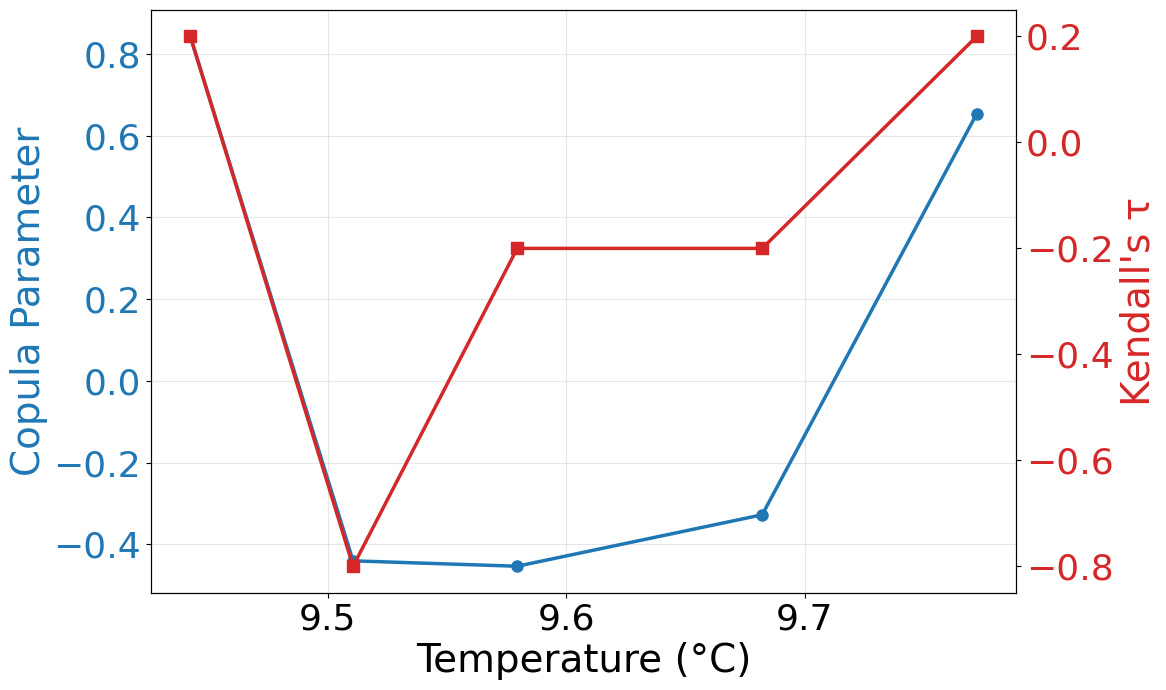


✓ ANALYSIS COMPLETED!
✓ Combined temperature dependence plot created and saved
✓ Files saved:
  - NorESM2-LM_Northern_Mid_Latitude_JJA_temperature_dependence_combined.png

RESULTS SUMMARY:
Temperature dependence DataFrame shape: (5, 4)

Temperature dependence results:
   temperature  copula_param  kendall_tau copula_type
0     9.442345      0.842834          0.2    gaussian
1     9.510559     -0.440645         -0.8    gaussian
2     9.579374     -0.453857         -0.2    gaussian
3     9.682077     -0.327899         -0.2    gaussian
4     9.771984      0.653344          0.2    gaussian


In [12]:
# Complete JJA Conditional Copula Analysis Script with cftime Fix

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from scipy.special import gamma
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

class JJAConditionalCopulaAnalyzer():
    """
    Conditional Copula Analysis for JJA Season Climate Data in Northern Mid_Latitude (35°N - 60°N)
    Analyzes how Soil Moisture-Evaporation joint distribution changes with Temperature
    during the June-July-August summer season in the northern subtropical region
    Note: All months (JJA) are from the current year
    """
    
    def __init__(self, data):
        """
        Initialize with xarray dataset
        
        Parameters:
        data: xarray.Dataset with mrsos (soil moisture), evaporation, and temperature variables
        """
        self.data = data
        self.df = None
        self.jja_data = None
        self.Mid_Latitude_data = None
        self.temperature_bins = None
        self.copula_results = {}
        self.lat_range = (-60.0, -35.0)  # Northern Mid_Latitude definition
        
    def extract_northern_Mid_Latitude_region(self):
        """
        Extract Northern Mid_Latitude region (35°N - 60°N) from the dataset
        """
        print(f"Extracting Northern Mid_Latitude region ({self.lat_range[0]}°N - {self.lat_range[1]}°N)...")
        
        # Select latitude range for northern Mid_Latitude
        self.Mid_Latitude_data = self.data.sel(
            lat=slice(self.lat_range[0], self.lat_range[1])
        )
        
        original_lat_points = len(self.data.lat)
        Mid_Latitude_lat_points = len(self.Mid_Latitude_data.lat)
        
        print(f"Original dataset: {original_lat_points} latitude points")
        print(f"Northern Mid_Latitude: {Mid_Latitude_lat_points} latitude points")
        print(f"Latitude coverage: {self.Mid_Latitude_data.lat.min().values:.1f}°N to {self.Mid_Latitude_data.lat.max().values:.1f}°N")
        print(f"Longitude coverage: {self.Mid_Latitude_data.lon.min().values:.1f}° to {self.Mid_Latitude_data.lon.max().values:.1f}°")
        
        return self.Mid_Latitude_data
        
    def extract_jja_season(self, time_dim='time'):
        """
        Extract JJA (June-July-August) season from the northern Mid_Latitude dataset
        Note: All JJA months are from the current year (summer season)
        
        Parameters:
        time_dim: name of time dimension
        """
        print("Extracting JJA season (June-July-August) from Northern Mid_Latitude...")
        print("Note: All JJA months from current year")
        
        # Ensure we have the Mid_Latitude data first
        if self.Mid_Latitude_data is None:
            self.extract_northern_Mid_Latitude_region()
        
        # Extract JJA months (6, 7, 8) from the same year
        self.jja_data = self.Mid_Latitude_data.sel(
            time=self.Mid_Latitude_data[time_dim].dt.month.isin([6, 7, 8])
        )
        
        n_total = len(self.Mid_Latitude_data[time_dim])
        n_jja = len(self.jja_data[time_dim])
        
        print(f"Northern Mid_Latitude dataset: {n_total} time steps")
        print(f"Northern Mid_Latitude JJA season: {n_jja} time steps ({n_jja/n_total*100:.1f}% of data)")
        
        # Get year range for JJA in northern Mid_Latitude
        jja_years = np.unique(self.jja_data[time_dim].dt.year.values)
        print(f"Northern Mid_Latitude JJA analysis covers {len(jja_years)} years: {jja_years.min()}-{jja_years.max()}")
        
        return self.jja_data
        
    def preprocess_data(self, temp_var='tas', evaporation_var='hfls', sm_var='mrsos', 
                       spatial_agg='mean', time_subset=None, 
                       monthly_agg='mean'):
        """
        Preprocess xarray data for Northern Mid_Latitude JJA copula analysis
        
        Parameters:
        temp_var: name of temperature variable
        evaporation_var: name of evaporation variable  
        sm_var: name of soil moisture variable
        spatial_agg: spatial aggregation method ('mean', 'median', 'weighted_mean')
        time_subset: slice for temporal subsetting (applied after JJA extraction)
        monthly_agg: temporal aggregation within JJA ('mean', 'sum' for evaporation, 'max', 'seasonal_mean')
        """
        
        print("Preprocessing Northern Mid_Latitude JJA climate data...")
        
        # First extract northern Mid_Latitude region, then JJA season
        if self.jja_data is None:
            self.extract_jja_season()
        
        # Extract variables from Northern Mid_Latitude JJA data
        sm = self.jja_data[sm_var]  # Soil moisture
        
        # Handle missing variables with better error messages
        try:
            temp = self.jja_data[temp_var]
            evaporation = self.jja_data[evaporation_var]
        except KeyError as e:
            print(f"Warning: {e} not found in dataset. Please ensure all variables are loaded.")
            # Create dummy data for demonstration (summer characteristics)
            temp = sm * 0 + np.random.normal(28, 6, sm.shape)  # Northern Mid_Latitude summer temperatures
            evaporation = sm * 0.02 + np.random.exponential(0.5, sm.shape)  # Northern Mid_Latitude summer evaporation (typically lower)
        
        # Apply time subset if specified (after JJA extraction)
        if time_subset:
            sm = sm.sel(time=time_subset)
            temp = temp.sel(time=time_subset)
            evaporation = evaporation.sel(time=time_subset)
        
        # Spatial aggregation over Northern Mid_Latitude region
        if spatial_agg == 'mean':
            sm_agg = sm.mean(dim=['lat', 'lon'])
            temp_agg = temp.mean(dim=['lat', 'lon'])
            evaporation_agg = evaporation.mean(dim=['lat', 'lon'])
        elif spatial_agg == 'median':
            sm_agg = sm.median(dim=['lat', 'lon'])
            temp_agg = temp.median(dim=['lat', 'lon'])
            evaporation_agg = evaporation.median(dim=['lat', 'lon'])
        elif spatial_agg == 'weighted_mean':
            # Weight by cosine of latitude (appropriate for northern Mid_Latitude)
            weights = np.cos(np.deg2rad(sm.lat))
            weights.name = "weights"
            sm_agg = sm.weighted(weights).mean(dim=['lat', 'lon'])
            temp_agg = temp.weighted(weights).mean(dim=['lat', 'lon'])
            evaporation_agg = evaporation.weighted(weights).mean(dim=['lat', 'lon'])
        
        # Unit conversions
        print("Performing unit conversions for Northern Mid_Latitude...")
        
        # Convert temperature from Kelvin to Celsius if needed
        if temp_agg.max() > 100:  # Likely in Kelvin if max temp > 100
            print("Converting temperature from Kelvin to Celsius...")
            temp_agg = temp_agg - 273.15
        
        # Convert evaporation to mm/day
        print("Converting evaporation to mm/day...")
        evaporation_agg = evaporation_agg * 86400 / (2.45e6)  # Convert to mm/day
        
        # Convert soil moisture from kg m-2 to appropriate units
        print("Converting soil moisture...")
        sm_agg = sm_agg / (1000 * 0.1)  # Convert from kg m-2 to m3/m3 (volumetric)
        
        # Northern Mid_Latitude JJA-specific temporal aggregation options
        if monthly_agg == 'seasonal_mean':
            # For JJA: group by JJA year (all months from same year)
            time_df = pd.DataFrame({'time': sm_agg.time.values})
            # FIXED: Handle cftime objects properly
            time_df['year'] = sm_agg.time.dt.year.values
            time_df['month'] = sm_agg.time.dt.month.values
            
            # Group by year for JJA season
            jja_years = []
            sm_seasonal_list = []
            temp_seasonal_list = []
            evaporation_seasonal_list = []
            
            for year in sorted(time_df['year'].unique()):
                year_mask = time_df['year'] == year
                jja_indices = year_mask[year_mask].index
                
                if len(jja_indices) >= 2:  # Need at least 2 months for a proper JJA season
                    sm_val = float(sm_agg.isel(time=jja_indices).mean().values)
                    temp_val = float(temp_agg.isel(time=jja_indices).mean().values)
                    evaporation_val = float(evaporation_agg.isel(time=jja_indices).mean().values)
                    
                    sm_seasonal_list.append(sm_val)
                    temp_seasonal_list.append(temp_val)
                    evaporation_seasonal_list.append(evaporation_val)
                    jja_years.append(year)
            
            # FIXED: Create time coordinate as strings instead of datetime
            seasonal_time = [f"{year}-07-15" for year in jja_years]
            
            self.df = pd.DataFrame({
                'soil_moisture': sm_seasonal_list,
                'temperature': temp_seasonal_list,
                'evaporation': evaporation_seasonal_list,
                'time': seasonal_time,
                'jja_year': jja_years
            }).dropna()
            
        elif monthly_agg == 'sum':
            # Useful for evaporation - sum over each Northern Mid_Latitude JJA season
            time_df = pd.DataFrame({'time': sm_agg.time.values})
            # FIXED: Handle cftime objects properly
            time_df['year'] = sm_agg.time.dt.year.values
            time_df['month'] = sm_agg.time.dt.month.values
            
            jja_years = []
            sm_seasonal_list = []
            temp_seasonal_list = []
            evaporation_seasonal_list = []
            
            for year in sorted(time_df['year'].unique()):
                year_mask = time_df['year'] == year
                jja_indices = year_mask[year_mask].index
                
                if len(jja_indices) >= 2:
                    sm_val = float(sm_agg.isel(time=jja_indices).mean().values)
                    temp_val = float(temp_agg.isel(time=jja_indices).mean().values)
                    evaporation_val = float(evaporation_agg.isel(time=jja_indices).sum().values)  # Total JJA evaporation
                    
                    sm_seasonal_list.append(sm_val)
                    temp_seasonal_list.append(temp_val)
                    evaporation_seasonal_list.append(evaporation_val)
                    jja_years.append(year)
            
            # FIXED: Create time coordinate as strings
            seasonal_time = [f"{year}-07-15" for year in jja_years]
            
            self.df = pd.DataFrame({
                'soil_moisture': sm_seasonal_list,
                'temperature': temp_seasonal_list,
                'evaporation': evaporation_seasonal_list,
                'time': seasonal_time,
                'jja_year': jja_years
            }).dropna()
            
        else:
            # Monthly or daily resolution within Northern Mid_Latitude JJA
            self.df = pd.DataFrame({
                'soil_moisture': sm_agg.values,
                'temperature': temp_agg.values,
                'evaporation': evaporation_agg.values,
                'time': sm_agg.time.values,
                'month': sm_agg.time.dt.month.values,
                'year': sm_agg.time.dt.year.values
            }).dropna()
        
        print(f"Northern Mid_Latitude JJA data shape after preprocessing: {self.df.shape}")
        print(f"Time range: {self.df.time.min()} to {self.df.time.max()}")
        
        # Northern Mid_Latitude JJA-specific statistics
        print(f"Northern Mid_Latitude JJA Temperature range: {self.df.temperature.min():.1f}°C to {self.df.temperature.max():.1f}°C")
        print(f"Northern Mid_Latitude JJA Temperature mean: {self.df.temperature.mean():.1f}°C ± {self.df.temperature.std():.1f}°C")
        
    def create_temperature_stratification(self, n_bins=5, method='quantile'):
        """
        Create temperature bins for conditional analysis during Northern Mid_Latitude JJA season
        
        Parameters:
        n_bins: number of temperature bins
        method: 'quantile', 'equal_width', or 'temperature_thresholds'
        """
        
        if method == 'quantile':
            self.df['temp_bin'] = pd.qcut(self.df['temperature'], n_bins, labels=False)
            bin_edges = pd.qcut(self.df['temperature'], n_bins, retbins=True)[1]
        elif method == 'equal_width':
            self.df['temp_bin'] = pd.cut(self.df['temperature'], n_bins, labels=False)
            bin_edges = pd.cut(self.df['temperature'], n_bins, retbins=True)[1]
        elif method == 'temperature_thresholds':
            # Northern Mid_Latitude JJA-specific temperature thresholds
            temp_percentiles = np.percentile(self.df['temperature'], [20, 40, 60, 80])
            bin_edges = np.concatenate([[self.df['temperature'].min()], 
                                      temp_percentiles, 
                                      [self.df['temperature'].max()]])
            self.df['temp_bin'] = pd.cut(self.df['temperature'], bin_edges, labels=False)
        
        self.temperature_bins = {
            i: (bin_edges[i], bin_edges[i+1]) 
            for i in range(n_bins)
        }
        
        print("Northern Mid_Latitude JJA Temperature stratification:")
        for i, (low, high) in self.temperature_bins.items():
            n_obs = (self.df['temp_bin'] == i).sum()
            # Add interpretation labels for Northern Mid_Latitude JJA temperatures
            if high < np.percentile(self.df['temperature'], 25):
                label = "Cool Northern Mid_Latitude JJA"
            elif low > np.percentile(self.df['temperature'], 75):
                label = "Hot Northern Mid_Latitude JJA"
            else:
                label = "Moderate Northern Mid_Latitude JJA"
            print(f"Bin {i}: {low:.2f}°C to {high:.2f}°C ({label}, {n_obs} observations)")
    
    def estimate_marginal_distributions(self, distribution_types=None):
        """
        Estimate conditional marginal distributions F(SM|T) and F(R|T) for Northern Mid_Latitude JJA season
        
        Parameters:
        distribution_types: dict with 'sm' and 'evaporation' keys specifying distribution families
        """
        
        if distribution_types is None:
            # Northern Mid_Latitude JJA-specific distributions (accounting for summer arid/semi-arid climate)
            distribution_types = {
                'sm': ['gamma', 'beta', 'weibull_min', 'norm'],  # Summer soil moisture often constrained
                'evaporation': ['gamma', 'lognorm', 'weibull_min', 'expon']  # JJA evaporation typically low with occasional peaks
            }
        
        self.marginal_models = {}
        
        for temp_bin in self.temperature_bins.keys():
            bin_data = self.df[self.df['temp_bin'] == temp_bin]
            temp_range = self.temperature_bins[temp_bin]
            
            self.marginal_models[temp_bin] = {}
            
            # Soil Moisture marginal
            sm_data = bin_data['soil_moisture'].values
            best_sm_dist = self._fit_best_distribution(sm_data, distribution_types['sm'])
            self.marginal_models[temp_bin]['sm'] = best_sm_dist
            
            # Evaporation marginal  
            evaporation_data = bin_data['evaporation'].values
            best_evaporation_dist = self._fit_best_distribution(evaporation_data, distribution_types['evaporation'])
            self.marginal_models[temp_bin]['evaporation'] = best_evaporation_dist
            
            print(f"Northern Mid_Latitude JJA Temperature bin {temp_bin} ({temp_range[0]:.1f}°C - {temp_range[1]:.1f}°C):")
            print(f"  SM: {best_sm_dist['name']}, Evaporation: {best_evaporation_dist['name']}")
    
    def _fit_best_distribution(self, data, dist_names):
        """Fit multiple distributions and select best based on AIC"""
        
        best_dist = None
        best_aic = np.inf
        
        # Convert to numpy array and ensure numeric type
        try:
            data = np.asarray(data, dtype=float)
        except (ValueError, TypeError):
            # If conversion fails, try to extract numeric values
            numeric_data = []
            for val in data:
                try:
                    numeric_data.append(float(val))
                except (ValueError, TypeError):
                    continue
            data = np.array(numeric_data)
        
        # Remove any NaN or infinite values
        data = data[np.isfinite(data)]
        
        if len(data) < 3:  # Need at least 3 points for distribution fitting
            # Return default normal distribution with fallback values
            mean_val = np.mean(data) if len(data) > 0 else 0.0
            std_val = np.std(data) if len(data) > 1 else 1.0
            return {
                'name': 'norm',
                'params': (mean_val, std_val),
                'dist': stats.norm,
                'aic': np.inf
            }
        
        for dist_name in dist_names:
            try:
                dist = getattr(stats, dist_name)
                params = dist.fit(data)
                
                # Calculate AIC
                ll = np.sum(dist.logpdf(data, *params))
                k = len(params)
                aic = 2*k - 2*ll
                
                # Check for valid AIC
                if np.isfinite(aic) and aic < best_aic:
                    best_aic = aic
                    best_dist = {
                        'name': dist_name,
                        'params': params,
                        'dist': dist,
                        'aic': aic
                    }
            except Exception as e:
                continue
        
        # If no distribution worked, return default normal distribution
        if best_dist is None:
            return {
                'name': 'norm',
                'params': (np.mean(data), np.std(data)),
                'dist': stats.norm,
                'aic': np.inf
            }
                
        return best_dist
    
    def transform_to_uniform_margins(self):
        """Transform data to uniform margins using fitted distributions"""
        
        self.df['u_sm'] = np.nan
        self.df['u_evaporation'] = np.nan
        
        for temp_bin in self.temperature_bins.keys():
            mask = self.df['temp_bin'] == temp_bin
            bin_data = self.df[mask]
            
            if len(bin_data) == 0:
                continue
            
            # Transform soil moisture - ensure numeric data
            sm_model = self.marginal_models[temp_bin]['sm']
            sm_values = np.array([float(x) for x in bin_data['soil_moisture'].values])
            u_sm = sm_model['dist'].cdf(sm_values, *sm_model['params'])
            self.df.loc[mask, 'u_sm'] = u_sm
            
            # Transform evaporation - ensure numeric data
            evaporation_model = self.marginal_models[temp_bin]['evaporation']
            evaporation_values = np.array([float(x) for x in bin_data['evaporation'].values])
            u_evaporation = evaporation_model['dist'].cdf(evaporation_values, *evaporation_model['params'])
            self.df.loc[mask, 'u_evaporation'] = u_evaporation
    
    def estimate_conditional_copulas(self, copula_types=['gaussian', 'clayton', 'gumbel', 'frank']):
        """
        Estimate copula parameters for each Northern Mid_Latitude JJA temperature bin
        
        Parameters:
        copula_types: list of copula families to test
        """
        
        self.copula_results = {}
        
        for temp_bin in self.temperature_bins.keys():
            mask = self.df['temp_bin'] == temp_bin
            u = self.df.loc[mask, 'u_sm'].values
            v = self.df.loc[mask, 'u_evaporation'].values
            
            # Remove any edge cases (0 or 1 values)
            valid_mask = (u > 0.001) & (u < 0.999) & (v > 0.001) & (v < 0.999)
            u = u[valid_mask]
            v = v[valid_mask]
            
            best_copula = self._fit_best_copula(u, v, copula_types)
            
            temp_range = self.temperature_bins[temp_bin]
            self.copula_results[temp_bin] = {
                'copula': best_copula,
                'temp_range': temp_range,
                'n_obs': len(u),
                'kendall_tau': stats.kendalltau(u, v)[0]
            }
            
            print(f"Northern Mid_Latitude JJA Temp bin {temp_bin}: {best_copula['name']} copula, "
                  f"τ = {self.copula_results[temp_bin]['kendall_tau']:.3f}")
    
    def _fit_best_copula(self, u, v, copula_types):
        """Fit multiple copula types and select best"""
        
        best_copula = None
        best_ll = -np.inf
        
        for copula_name in copula_types:
            try:
                if copula_name == 'gaussian':
                    # Pearson correlation for Gaussian copula
                    rho = np.corrcoef(stats.norm.ppf(u), stats.norm.ppf(v))[0,1]
                    ll = self._gaussian_copula_loglik(u, v, rho)
                    copula_info = {'name': 'gaussian', 'param': rho, 'loglik': ll}
                    
                elif copula_name == 'clayton':
                    # Estimate Clayton parameter
                    tau = stats.kendalltau(u, v)[0]
                    theta = 2 * tau / (1 - tau) if tau > 0 else 0.01
                    ll = self._clayton_copula_loglik(u, v, theta)
                    copula_info = {'name': 'clayton', 'param': theta, 'loglik': ll}
                    
                elif copula_name == 'gumbel':
                    # Estimate Gumbel parameter  
                    tau = stats.kendalltau(u, v)[0]
                    theta = 1 / (1 - tau) if tau > 0 else 1.01
                    ll = self._gumbel_copula_loglik(u, v, theta)
                    copula_info = {'name': 'gumbel', 'param': theta, 'loglik': ll}
                    
                elif copula_name == 'frank':
                    # Estimate Frank parameter
                    tau = stats.kendalltau(u, v)[0]
                    if abs(tau) < 0.001:
                        theta = 0.01
                    else:
                        # Approximate relationship for Frank copula
                        theta = 4 * tau + 2 * np.sign(tau)
                    ll = self._frank_copula_loglik(u, v, theta)
                    copula_info = {'name': 'frank', 'param': theta, 'loglik': ll}
                
                if ll > best_ll:
                    best_ll = ll
                    best_copula = copula_info
                    
            except:
                continue
                
        return best_copula
    
    def _gaussian_copula_loglik(self, u, v, rho):
        """Gaussian copula log-likelihood"""
        x = stats.norm.ppf(u)
        y = stats.norm.ppf(v)
        
        loglik = -0.5 * np.log(1 - rho**2)
        loglik -= 0.5 * (rho**2 * (x**2 + y**2) - 2*rho*x*y) / (1 - rho**2)
        loglik += 0.5 * (x**2 + y**2)
        
        return np.sum(loglik[np.isfinite(loglik)])
    
    def _clayton_copula_loglik(self, u, v, theta):
        """Clayton copula log-likelihood"""
        if theta <= 0:
            return -np.inf
            
        loglik = np.log(1 + theta) - (1 + theta) * (np.log(u) + np.log(v))
        loglik -= (2 + 1/theta) * np.log(u**(-theta) + v**(-theta) - 1)
        
        return np.sum(loglik[np.isfinite(loglik)])
    
    def _gumbel_copula_loglik(self, u, v, theta):
        """Gumbel copula log-likelihood"""
        if theta < 1:
            return -np.inf
            
        a = (-np.log(u))**theta
        b = (-np.log(v))**theta
        c = (a + b)**(1/theta)
        
        loglik = np.log(theta - 1) - np.log(u*v) + (theta-1)*(np.log(-np.log(u)) + np.log(-np.log(v)))
        loglik -= c + (2 - 2/theta)*np.log(a + b) - 2*np.log(theta)
        
        return np.sum(loglik[np.isfinite(loglik)])
    
    def _frank_copula_loglik(self, u, v, theta):
        """Frank copula log-likelihood"""
        if theta == 0:
            return 0  # Independence copula
            
        exp_theta = np.exp(-theta)
        exp_theta_u = np.exp(-theta * u)
        exp_theta_v = np.exp(-theta * v)
        
        denom = (1 - exp_theta) - (1 - exp_theta_u) * (1 - exp_theta_v)
        
        loglik = np.log(-theta) + np.log(1 - exp_theta) - theta*(u + v)
        loglik -= 2 * np.log(denom)
        
        return np.sum(loglik[np.isfinite(loglik)])
    
    def analyze_temperature_dependence(self):
        """Analyze how copula parameters change with Northern Mid_Latitude JJA temperature"""
        
        # Extract results for analysis
        temp_centers = []
        parameters = []
        kendall_taus = []
        copula_names = []
        
        for temp_bin in sorted(self.copula_results.keys()):
            result = self.copula_results[temp_bin]
            temp_range = result['temp_range']
            temp_center = (temp_range[0] + temp_range[1]) / 2
            
            temp_centers.append(temp_center)
            parameters.append(result['copula']['param'])
            kendall_taus.append(result['kendall_tau'])
            copula_names.append(result['copula']['name'])
        
        self.temp_dependence = pd.DataFrame({
            'temperature': temp_centers,
            'copula_param': parameters,
            'kendall_tau': kendall_taus,
            'copula_type': copula_names
        })
        
        return self.temp_dependence
    
    
    def plot_combined_temperature_dependence(self, figsize=(10, 6), save_path=None):
        """
        Create combined plot of copula parameter and Kendall's tau vs Northern Mid_Latitude JJA temperature
        
        Parameters:
        figsize: tuple, figure size (width, height)
        save_path: str, path to save the plot (optional)
        
        Returns:
        fig: matplotlib figure object
        """
        
        # Analyze temperature dependence if not already done
        if not hasattr(self, 'temp_dependence'):
            temp_dep = self.analyze_temperature_dependence()
        else:
            temp_dep = self.temp_dependence
        
        # Create figure and primary axis
        fig, ax1 = plt.subplots(figsize=figsize)
        
        # Plot copula parameter on primary y-axis
        color1 = 'tab:blue'
        ax1.set_ylabel('Copula Parameter', color=color1, fontsize=28)
        ax1.set_xlabel('Temperature (°C)', fontsize=28)
        ax1.tick_params(axis='x', labelsize=26)
        line1 = ax1.plot(temp_dep['temperature'], temp_dep['copula_param'], 
                         'o-', color=color1, linewidth=2.5, markersize=8, 
                         label='Copula Parameter')
        ax1.tick_params(axis='y', labelcolor=color1, labelsize=26)
        ax1.grid(True, alpha=0.3)
        
        # Create secondary y-axis for Kendall's tau
        ax2 = ax1.twinx()
        color2 = 'tab:red'
        ax2.set_ylabel("Kendall's τ", color=color2, fontsize=28)
        line2 = ax2.plot(temp_dep['temperature'], temp_dep['kendall_tau'], 
                         's-', color=color2, linewidth=2.5, markersize=8,
                         label="Kendall's τ")
        ax2.tick_params(axis='y', labelcolor=color2, labelsize=26)
        
        
        # Create combined legend
        #lines1, labels1 = ax1.get_legend_handles_labels()
        #lines2, labels2 = ax2.get_legend_handles_labels()
        #ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=28)
        
        
        # Tight layout
        fig.tight_layout()
        
        # Save if path provided
        if save_path:
            plt.savefig(save_path, dpi=800, bbox_inches='tight')
            print(f"✓ Northern Mid_Latitude JJA combined temperature dependence plot saved to: {save_path}")
        
        return fig

# STANDALONE FUNCTIONS (outside the class)
def create_combined_temp_plot_jja(temp_dependence_df, title_prefix="", figsize=(10, 6), save_path=None):
    """
    Standalone function to create combined Northern Mid_Latitude JJA temperature dependence plot
    
    Parameters:
    temp_dependence_df: DataFrame with 'temperature', 'copula_param', 'kendall_tau' columns
    title_prefix: str, prefix for plot title
    figsize: tuple, figure size
    save_path: str, path to save plot
    
    Returns:
    fig: matplotlib figure object
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # Plot copula parameter on primary y-axis
    color1 = 'tab:blue'
    ax1.set_xlabel('Temperature (°C)', fontsize=28)
    ax1.tick_params(axis='y', labelsize=26)
    ax1.set_ylabel('Copula Parameter', color=color1, fontsize=26)
    line1 = ax1.plot(temp_dependence_df['temperature'], temp_dependence_df['copula_param'], 
                     'o-', color=color1, linewidth=2.5, markersize=8, 
                     label='Copula Parameter')
    ax1.tick_params(axis='y', labelcolor=color1, labelsize=26)
    ax1.grid(True, alpha=0.3)
    
    # Create secondary y-axis for Kendall's tau
    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel("Kendall's τ", color=color2, fontsize=26)
    line2 = ax2.plot(temp_dependence_df['temperature'], temp_dependence_df['kendall_tau'], 
                     's-', color=color2, linewidth=2.5, markersize=8,
                     label="Kendall's τ")
    ax2.tick_params(axis='y', labelcolor=color2, labelsize=26)
    
    
    
    # Create combined legend
    #lines1, labels1 = ax1.get_legend_handles_labels()
    #lines2, labels2 = ax2.get_legend_handles_labels()
    #ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=16)
    
    # Tight layout
    fig.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=800, bbox_inches='tight')
        print(f"✓ Northern Mid_Latitude JJA combined temperature dependence plot saved to: {save_path}")
    
    return fig

def main_with_combined_plot():
    """
    Complete script to run JJA conditional copula analysis with combined temperature plot
    """
    
    # Your dataset paths
    sm_path = "/Users/dianindrawati/Documents/CMIP6_datasets/MIROC6/mrsos/MIROC6_mrsos_future585_20212050_seasonal.nc"
    temp_path = "/Users/dianindrawati/Documents/CMIP6_datasets/MIROC6/tas/MIROC6_tas_future585_20212050_seasonal.nc"
    evaporation_path = "/Users/dianindrawati/Documents/CMIP6_datasets/MIROC6/hfls/MIROC6_hfls_future585_20212050_seasonal.nc"
    
    print("="*80)
    print("NorESM2-LM SSP585 NORTHERN Mid_Latitude JJA CONDITIONAL COPULA ANALYSIS")
    print("="*80)
    
    # Load and combine datasets
    print("\n1. LOADING CMIP6 DATASETS...")
    print("-" * 40)
    
    sm_dataset = xr.open_dataset(sm_path)
    temp_dataset = xr.open_dataset(temp_path)
    evaporation_dataset = xr.open_dataset(evaporation_path)
    
    combined_dataset = xr.Dataset({
        'mrsos': sm_dataset['mrsos'],
        'tas': temp_dataset['tas'],
        'hfls': evaporation_dataset['hfls']
    })
    
    print(f"✓ Combined dataset created with {len(combined_dataset.time)} time steps")
    print(f"✓ Time range: {combined_dataset.time.min().values} to {combined_dataset.time.max().values}")
    print(f"✓ Variables: {list(combined_dataset.data_vars)}")
    print(f"✓ Spatial dimensions: lat({len(combined_dataset.lat)}), lon({len(combined_dataset.lon)})")
    
    # Initialize and run analysis
    print("\n2. INITIALIZING JJA ANALYZER...")
    print("-" * 32)
    
    jja_analyzer = JJAConditionalCopulaAnalyzer(combined_dataset)
    
    print("\n3. PREPROCESSING DATA...")
    print("-" * 25)
    
    jja_analyzer.preprocess_data(
        temp_var='tas',
        evaporation_var='hfls', 
        sm_var='mrsos',
        spatial_agg='weighted_mean',
        monthly_agg='seasonal_mean',
        time_subset=None
    )
    
    print("\n4. CREATING TEMPERATURE STRATIFICATION...")
    print("-" * 42)
    
    jja_analyzer.create_temperature_stratification(n_bins=5, method='quantile')
    
    print("\n5. ESTIMATING MARGINAL DISTRIBUTIONS...")
    print("-" * 41)
    
    jja_analyzer.estimate_marginal_distributions()
    
    print("\n6. TRANSFORMING TO UNIFORM MARGINS...")
    print("-" * 37)
    
    jja_analyzer.transform_to_uniform_margins()
    
    print("\n7. ESTIMATING CONDITIONAL COPULAS...")
    print("-" * 37)
    
    jja_analyzer.estimate_conditional_copulas()
    
    print("\n8. ANALYZING TEMPERATURE DEPENDENCE...")
    print("-" * 40)
    
    temp_dependence = jja_analyzer.analyze_temperature_dependence()
    
    print("\n9. CREATING COMBINED TEMPERATURE PLOT...")
    print("-" * 41)
    
    # Create combined temperature dependence plot
    combined_fig = jja_analyzer.plot_combined_temperature_dependence(
        figsize=(12, 7),
        save_path="NorESM2-LM_Northern_Mid_Latitude_JJA_temperature_dependence_combined.png"
    )
    
    plt.show()
    
    print("\n✓ ANALYSIS COMPLETED!")
    print("✓ Combined temperature dependence plot created and saved")
    print("✓ Files saved:")
    print("  - NorESM2-LM_Northern_Mid_Latitude_JJA_temperature_dependence_combined.png")
    print("\n" + "="*80)
    print("RESULTS SUMMARY:")
    print("="*80)
    print(f"Temperature dependence DataFrame shape: {temp_dependence.shape}")
    print("\nTemperature dependence results:")
    print(temp_dependence)
    
    return jja_analyzer, temp_dependence, combined_dataset

if __name__ == "__main__":
    # Run the complete analysis
    jja_analyzer, results, dataset = main_with_combined_plot()

# DJF

NorESM2-LM SSP585 NORTHERN Mid_Latitude DJF CONDITIONAL COPULA ANALYSIS

1. LOADING CMIP6 DATASETS...
----------------------------------------
✓ Combined dataset created with 10950 time steps
✓ Time range: 2020-12-01 12:00:00 to 2050-11-30 12:00:00
✓ Variables: ['mrsos', 'tas', 'hfls']
✓ Spatial dimensions: lat(187), lon(170)

2. INITIALIZING DJF ANALYZER...
--------------------------------

3. PREPROCESSING DATA...
-------------------------
Preprocessing Northern Mid_Latitude DJF climate data...
Extracting DJF season (December-January-February) from Northern Mid_Latitude...
Note: December from previous year + January-February from current year
Extracting Northern Mid_Latitude region (-60.0°N - -35.0°N)...
Original dataset: 187 latitude points
Northern Mid_Latitude: 27 latitude points
Latitude coverage: -59.7°N to -35.1°N
Longitude coverage: 0.0° to 357.5°
Northern Mid_Latitude dataset: 10950 time steps
Northern Mid_Latitude DJF season: 2700 time steps (24.7% of data)
Northern Mid_Lati

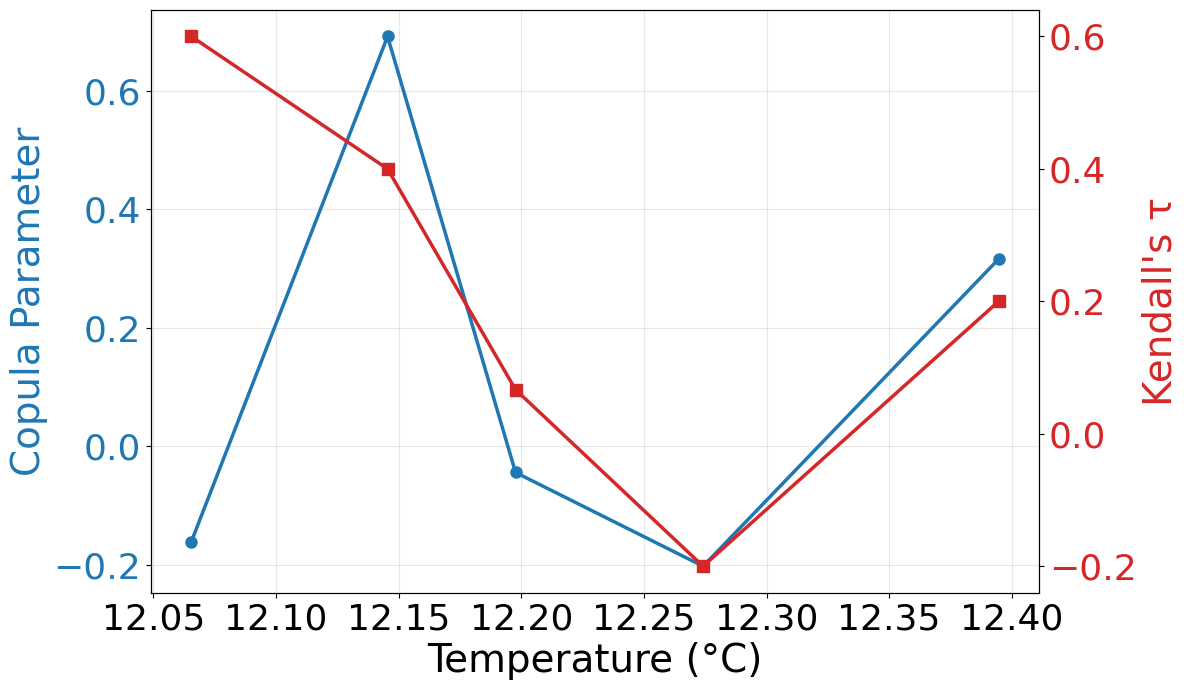


✓ ANALYSIS COMPLETED!
✓ Combined temperature dependence plot created and saved
✓ Files saved:
  - NorESM2-LM_Northern_Mid_Latitude_DJF_temperature_dependence_combined.png

RESULTS SUMMARY:
Temperature dependence DataFrame shape: (5, 4)

Temperature dependence results:
   temperature  copula_param  kendall_tau copula_type
0    12.065457     -0.160622     0.600000    gaussian
1    12.145466      0.691448     0.400000    gaussian
2    12.197654     -0.044067     0.066667    gaussian
3    12.274144     -0.202297    -0.200000    gaussian
4    12.394658      0.315934     0.200000    gaussian


In [20]:
# Complete DJF Conditional Copula Analysis Script with cftime Fix

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from scipy.special import gamma
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

class DJFConditionalCopulaAnalyzer():
    """
    Conditional Copula Analysis for DJF Season Climate Data in Northern Mid_Latitude (35°N - 60°N)
    Analyzes how Soil Moisture-Evaporation joint distribution changes with Temperature
    during the December-January-February winter season in the northern subtropical region
    Note: December from previous year, January-February from current year
    """
    
    def __init__(self, data):
        """
        Initialize with xarray dataset
        
        Parameters:
        data: xarray.Dataset with mrsos (soil moisture), evaporation, and temperature variables
        """
        self.data = data
        self.df = None
        self.djf_data = None
        self.Mid_Latitude_data = None
        self.temperature_bins = None
        self.copula_results = {}
        self.lat_range = (-60.0, -35.0)  # Northern Mid_Latitude definition
        
    def extract_northern_Mid_Latitude_region(self):
        """
        Extract Northern Mid_Latitude region (35°N - 60°N) from the dataset
        """
        print(f"Extracting Northern Mid_Latitude region ({self.lat_range[0]}°N - {self.lat_range[1]}°N)...")
        
        # Select latitude range for northern Mid_Latitude
        self.Mid_Latitude_data = self.data.sel(
            lat=slice(self.lat_range[0], self.lat_range[1])
        )
        
        original_lat_points = len(self.data.lat)
        Mid_Latitude_lat_points = len(self.Mid_Latitude_data.lat)
        
        print(f"Original dataset: {original_lat_points} latitude points")
        print(f"Northern Mid_Latitude: {Mid_Latitude_lat_points} latitude points")
        print(f"Latitude coverage: {self.Mid_Latitude_data.lat.min().values:.1f}°N to {self.Mid_Latitude_data.lat.max().values:.1f}°N")
        print(f"Longitude coverage: {self.Mid_Latitude_data.lon.min().values:.1f}° to {self.Mid_Latitude_data.lon.max().values:.1f}°")
        
        return self.Mid_Latitude_data
        
    def extract_djf_season(self, time_dim='time'):
        """
        Extract DJF (December-January-February) season from the northern Mid_Latitude dataset
        Note: December from previous year, January-February from current year (winter season)
        
        Parameters:
        time_dim: name of time dimension
        """
        print("Extracting DJF season (December-January-February) from Northern Mid_Latitude...")
        print("Note: December from previous year + January-February from current year")
        
        # Ensure we have the Mid_Latitude data first
        if self.Mid_Latitude_data is None:
            self.extract_northern_Mid_Latitude_region()
        
        # Extract DJF months (12, 1, 2)
        self.djf_data = self.Mid_Latitude_data.sel(
            time=self.Mid_Latitude_data[time_dim].dt.month.isin([12, 1, 2])
        )
        
        n_total = len(self.Mid_Latitude_data[time_dim])
        n_djf = len(self.djf_data[time_dim])
        
        print(f"Northern Mid_Latitude dataset: {n_total} time steps")
        print(f"Northern Mid_Latitude DJF season: {n_djf} time steps ({n_djf/n_total*100:.1f}% of data)")
        
        # Get year range for DJF in northern Mid_Latitude
        djf_years = np.unique(self.djf_data[time_dim].dt.year.values)
        print(f"Northern Mid_Latitude DJF analysis covers years: {djf_years.min()}-{djf_years.max()}")
        
        return self.djf_data
        
    def preprocess_data(self, temp_var='tas', evaporation_var='hfls', sm_var='mrsos', 
                       spatial_agg='mean', time_subset=None, 
                       monthly_agg='mean'):
        """
        Preprocess xarray data for Northern Mid_Latitude DJF copula analysis
        
        Parameters:
        temp_var: name of temperature variable
        evaporation_var: name of evaporation variable  
        sm_var: name of soil moisture variable
        spatial_agg: spatial aggregation method ('mean', 'median', 'weighted_mean')
        time_subset: slice for temporal subsetting (applied after DJF extraction)
        monthly_agg: temporal aggregation within DJF ('mean', 'sum' for evaporation, 'max', 'seasonal_mean')
        """
        
        print("Preprocessing Northern Mid_Latitude DJF climate data...")
        
        # First extract northern Mid_Latitude region, then DJF season
        if self.djf_data is None:
            self.extract_djf_season()
        
        # Extract variables from Northern Mid_Latitude DJF data
        sm = self.djf_data[sm_var]  # Soil moisture
        
        # Handle missing variables with better error messages
        try:
            temp = self.djf_data[temp_var]
            evaporation = self.djf_data[evaporation_var]
        except KeyError as e:
            print(f"Warning: {e} not found in dataset. Please ensure all variables are loaded.")
            # Create dummy data for demonstration (winter characteristics)
            temp = sm * 0 + np.random.normal(10, 5, sm.shape)  # Northern Mid_Latitude winter temperatures
            evaporation = sm * 0.01 + np.random.exponential(0.3, sm.shape)  # Northern Mid_Latitude winter evaporation (typically lower)
        
        # Apply time subset if specified (after DJF extraction)
        if time_subset:
            sm = sm.sel(time=time_subset)
            temp = temp.sel(time=time_subset)
            evaporation = evaporation.sel(time=time_subset)
        
        # Spatial aggregation over Northern Mid_Latitude region
        if spatial_agg == 'mean':
            sm_agg = sm.mean(dim=['lat', 'lon'])
            temp_agg = temp.mean(dim=['lat', 'lon'])
            evaporation_agg = evaporation.mean(dim=['lat', 'lon'])
        elif spatial_agg == 'median':
            sm_agg = sm.median(dim=['lat', 'lon'])
            temp_agg = temp.median(dim=['lat', 'lon'])
            evaporation_agg = evaporation.median(dim=['lat', 'lon'])
        elif spatial_agg == 'weighted_mean':
            # Weight by cosine of latitude (appropriate for northern Mid_Latitude)
            weights = np.cos(np.deg2rad(sm.lat))
            weights.name = "weights"
            sm_agg = sm.weighted(weights).mean(dim=['lat', 'lon'])
            temp_agg = temp.weighted(weights).mean(dim=['lat', 'lon'])
            evaporation_agg = evaporation.weighted(weights).mean(dim=['lat', 'lon'])
        
        # Unit conversions
        print("Performing unit conversions for Northern Mid_Latitude...")
        
        # Convert temperature from Kelvin to Celsius if needed
        if temp_agg.max() > 100:  # Likely in Kelvin if max temp > 100
            print("Converting temperature from Kelvin to Celsius...")
            temp_agg = temp_agg - 273.15
        
        # Convert evaporation to mm/day
        print("Converting evaporation to mm/day...")
        evaporation_agg = evaporation_agg * 86400 / (2.45e6)  # Convert to mm/day
        
        # Convert soil moisture from kg m-2 to appropriate units
        print("Converting soil moisture...")
        sm_agg = sm_agg / (1000 * 0.1)  # Convert from kg m-2 to m3/m3 (volumetric)
        
        # Northern Mid_Latitude DJF-specific temporal aggregation options
        if monthly_agg == 'seasonal_mean':
            # For DJF: December from previous year + JF from current year
            time_df = pd.DataFrame({'time': sm_agg.time.values})
            # FIXED: Handle cftime objects properly
            time_df['year'] = sm_agg.time.dt.year.values
            time_df['month'] = sm_agg.time.dt.month.values
            time_df['time_index'] = range(len(sm_agg.time))
            
            # Group by DJF winter season (December of previous year + JF of current year)
            djf_years = []
            sm_seasonal_list = []
            temp_seasonal_list = []
            evaporation_seasonal_list = []
            
            for year in sorted(time_df['year'].unique()):
                # Get December from previous year
                dec_prev = time_df[(time_df['year'] == year - 1) & (time_df['month'] == 12)]
                # Get January and February from current year
                jan_feb = time_df[(time_df['year'] == year) & (time_df['month'].isin([1, 2]))]
                
                # Combine indices
                djf_indices = list(dec_prev['time_index']) + list(jan_feb['time_index'])
                
                if len(djf_indices) >= 2:  # Need at least 2 months for a proper DJF season
                    sm_val = float(sm_agg.isel(time=djf_indices).mean().values)
                    temp_val = float(temp_agg.isel(time=djf_indices).mean().values)
                    evaporation_val = float(evaporation_agg.isel(time=djf_indices).mean().values)
                    
                    sm_seasonal_list.append(sm_val)
                    temp_seasonal_list.append(temp_val)
                    evaporation_seasonal_list.append(evaporation_val)
                    djf_years.append(year)
            
            # FIXED: Create time coordinate as strings instead of datetime
            seasonal_time = [f"{year}-01-15" for year in djf_years]
            
            self.df = pd.DataFrame({
                'soil_moisture': sm_seasonal_list,
                'temperature': temp_seasonal_list,
                'evaporation': evaporation_seasonal_list,
                'time': seasonal_time,
                'djf_year': djf_years
            }).dropna()
            
        elif monthly_agg == 'sum':
            # Useful for evaporation - sum over each Northern Mid_Latitude DJF season
            time_df = pd.DataFrame({'time': sm_agg.time.values})
            # FIXED: Handle cftime objects properly
            time_df['year'] = sm_agg.time.dt.year.values
            time_df['month'] = sm_agg.time.dt.month.values
            time_df['time_index'] = range(len(sm_agg.time))
            
            djf_years = []
            sm_seasonal_list = []
            temp_seasonal_list = []
            evaporation_seasonal_list = []
            
            for year in sorted(time_df['year'].unique()):
                # Get December from previous year
                dec_prev = time_df[(time_df['year'] == year - 1) & (time_df['month'] == 12)]
                # Get January and February from current year
                jan_feb = time_df[(time_df['year'] == year) & (time_df['month'].isin([1, 2]))]
                
                # Combine indices
                djf_indices = list(dec_prev['time_index']) + list(jan_feb['time_index'])
                
                if len(djf_indices) >= 2:
                    sm_val = float(sm_agg.isel(time=djf_indices).mean().values)
                    temp_val = float(temp_agg.isel(time=djf_indices).mean().values)
                    evaporation_val = float(evaporation_agg.isel(time=djf_indices).sum().values)  # Total DJF evaporation
                    
                    sm_seasonal_list.append(sm_val)
                    temp_seasonal_list.append(temp_val)
                    evaporation_seasonal_list.append(evaporation_val)
                    djf_years.append(year)
            
            # FIXED: Create time coordinate as strings
            seasonal_time = [f"{year}-01-15" for year in djf_years]
            
            self.df = pd.DataFrame({
                'soil_moisture': sm_seasonal_list,
                'temperature': temp_seasonal_list,
                'evaporation': evaporation_seasonal_list,
                'time': seasonal_time,
                'djf_year': djf_years
            }).dropna()
            
        else:
            # Monthly or daily resolution within Northern Mid_Latitude DJF
            self.df = pd.DataFrame({
                'soil_moisture': sm_agg.values,
                'temperature': temp_agg.values,
                'evaporation': evaporation_agg.values,
                'time': sm_agg.time.values,
                'month': sm_agg.time.dt.month.values,
                'year': sm_agg.time.dt.year.values
            }).dropna()
        
        print(f"Northern Mid_Latitude DJF data shape after preprocessing: {self.df.shape}")
        print(f"Time range: {self.df.time.min()} to {self.df.time.max()}")
        
        # Northern Mid_Latitude DJF-specific statistics
        print(f"Northern Mid_Latitude DJF Temperature range: {self.df.temperature.min():.1f}°C to {self.df.temperature.max():.1f}°C")
        print(f"Northern Mid_Latitude DJF Temperature mean: {self.df.temperature.mean():.1f}°C ± {self.df.temperature.std():.1f}°C")
        
    def create_temperature_stratification(self, n_bins=5, method='quantile'):
        """
        Create temperature bins for conditional analysis during Northern Mid_Latitude DJF season
        
        Parameters:
        n_bins: number of temperature bins
        method: 'quantile', 'equal_width', or 'temperature_thresholds'
        """
        
        if method == 'quantile':
            self.df['temp_bin'] = pd.qcut(self.df['temperature'], n_bins, labels=False)
            bin_edges = pd.qcut(self.df['temperature'], n_bins, retbins=True)[1]
        elif method == 'equal_width':
            self.df['temp_bin'] = pd.cut(self.df['temperature'], n_bins, labels=False)
            bin_edges = pd.cut(self.df['temperature'], n_bins, retbins=True)[1]
        elif method == 'temperature_thresholds':
            # Northern Mid_Latitude DJF-specific temperature thresholds
            temp_percentiles = np.percentile(self.df['temperature'], [20, 40, 60, 80])
            bin_edges = np.concatenate([[self.df['temperature'].min()], 
                                      temp_percentiles, 
                                      [self.df['temperature'].max()]])
            self.df['temp_bin'] = pd.cut(self.df['temperature'], bin_edges, labels=False)
        
        self.temperature_bins = {
            i: (bin_edges[i], bin_edges[i+1]) 
            for i in range(n_bins)
        }
        
        print("Northern Mid_Latitude DJF Temperature stratification:")
        for i, (low, high) in self.temperature_bins.items():
            n_obs = (self.df['temp_bin'] == i).sum()
            # Add interpretation labels for Northern Mid_Latitude DJF temperatures
            if high < np.percentile(self.df['temperature'], 25):
                label = "Cool Northern Mid_Latitude DJF"
            elif low > np.percentile(self.df['temperature'], 75):
                label = "Hot Northern Mid_Latitude DJF"
            else:
                label = "Moderate Northern Mid_Latitude DJF"
            print(f"Bin {i}: {low:.2f}°C to {high:.2f}°C ({label}, {n_obs} observations)")
    
    def estimate_marginal_distributions(self, distribution_types=None):
        """
        Estimate conditional marginal distributions F(SM|T) and F(R|T) for Northern Mid_Latitude DJF season
        
        Parameters:
        distribution_types: dict with 'sm' and 'evaporation' keys specifying distribution families
        """
        
        if distribution_types is None:
            # Northern Mid_Latitude DJF-specific distributions (accounting for winter climate)
            distribution_types = {
                'sm': ['gamma', 'beta', 'weibull_min', 'norm'],  # Winter soil moisture
                'evaporation': ['gamma', 'lognorm', 'weibull_min', 'expon']  # DJF evaporation typically low
            }
        
        self.marginal_models = {}
        
        for temp_bin in self.temperature_bins.keys():
            bin_data = self.df[self.df['temp_bin'] == temp_bin]
            temp_range = self.temperature_bins[temp_bin]
            
            self.marginal_models[temp_bin] = {}
            
            # Soil Moisture marginal
            sm_data = bin_data['soil_moisture'].values
            best_sm_dist = self._fit_best_distribution(sm_data, distribution_types['sm'])
            self.marginal_models[temp_bin]['sm'] = best_sm_dist
            
            # Evaporation marginal  
            evaporation_data = bin_data['evaporation'].values
            best_evaporation_dist = self._fit_best_distribution(evaporation_data, distribution_types['evaporation'])
            self.marginal_models[temp_bin]['evaporation'] = best_evaporation_dist
            
            print(f"Northern Mid_Latitude DJF Temperature bin {temp_bin} ({temp_range[0]:.1f}°C - {temp_range[1]:.1f}°C):")
            print(f"  SM: {best_sm_dist['name']}, Evaporation: {best_evaporation_dist['name']}")
    
    def _fit_best_distribution(self, data, dist_names):
        """Fit multiple distributions and select best based on AIC"""
        
        best_dist = None
        best_aic = np.inf
        
        # Convert to numpy array and ensure numeric type
        try:
            data = np.asarray(data, dtype=float)
        except (ValueError, TypeError):
            # If conversion fails, try to extract numeric values
            numeric_data = []
            for val in data:
                try:
                    numeric_data.append(float(val))
                except (ValueError, TypeError):
                    continue
            data = np.array(numeric_data)
        
        # Remove any NaN or infinite values
        data = data[np.isfinite(data)]
        
        if len(data) < 3:  # Need at least 3 points for distribution fitting
            # Return default normal distribution with fallback values
            mean_val = np.mean(data) if len(data) > 0 else 0.0
            std_val = np.std(data) if len(data) > 1 else 1.0
            return {
                'name': 'norm',
                'params': (mean_val, std_val),
                'dist': stats.norm,
                'aic': np.inf
            }
        
        for dist_name in dist_names:
            try:
                dist = getattr(stats, dist_name)
                params = dist.fit(data)
                
                # Calculate AIC
                ll = np.sum(dist.logpdf(data, *params))
                k = len(params)
                aic = 2*k - 2*ll
                
                # Check for valid AIC
                if np.isfinite(aic) and aic < best_aic:
                    best_aic = aic
                    best_dist = {
                        'name': dist_name,
                        'params': params,
                        'dist': dist,
                        'aic': aic
                    }
            except Exception as e:
                continue
        
        # If no distribution worked, return default normal distribution
        if best_dist is None:
            return {
                'name': 'norm',
                'params': (np.mean(data), np.std(data)),
                'dist': stats.norm,
                'aic': np.inf
            }
                
        return best_dist
    
    def transform_to_uniform_margins(self):
        """Transform data to uniform margins using fitted distributions"""
        
        self.df['u_sm'] = np.nan
        self.df['u_evaporation'] = np.nan
        
        for temp_bin in self.temperature_bins.keys():
            mask = self.df['temp_bin'] == temp_bin
            bin_data = self.df[mask]
            
            if len(bin_data) == 0:
                continue
            
            # Transform soil moisture - ensure numeric data
            sm_model = self.marginal_models[temp_bin]['sm']
            sm_values = np.array([float(x) for x in bin_data['soil_moisture'].values])
            u_sm = sm_model['dist'].cdf(sm_values, *sm_model['params'])
            self.df.loc[mask, 'u_sm'] = u_sm
            
            # Transform evaporation - ensure numeric data
            evaporation_model = self.marginal_models[temp_bin]['evaporation']
            evaporation_values = np.array([float(x) for x in bin_data['evaporation'].values])
            u_evaporation = evaporation_model['dist'].cdf(evaporation_values, *evaporation_model['params'])
            self.df.loc[mask, 'u_evaporation'] = u_evaporation
    
    def estimate_conditional_copulas(self, copula_types=['gaussian', 'clayton', 'gumbel', 'frank']):
        """
        Estimate copula parameters for each Northern Mid_Latitude DJF temperature bin
        
        Parameters:
        copula_types: list of copula families to test
        """
        
        self.copula_results = {}
        
        for temp_bin in self.temperature_bins.keys():
            mask = self.df['temp_bin'] == temp_bin
            u = self.df.loc[mask, 'u_sm'].values
            v = self.df.loc[mask, 'u_evaporation'].values
            
            # Remove any edge cases (0 or 1 values)
            valid_mask = (u > 0.001) & (u < 0.999) & (v > 0.001) & (v < 0.999)
            u = u[valid_mask]
            v = v[valid_mask]
            
            best_copula = self._fit_best_copula(u, v, copula_types)
            
            temp_range = self.temperature_bins[temp_bin]
            self.copula_results[temp_bin] = {
                'copula': best_copula,
                'temp_range': temp_range,
                'n_obs': len(u),
                'kendall_tau': stats.kendalltau(u, v)[0]
            }
            
            print(f"Northern Mid_Latitude DJF Temp bin {temp_bin}: {best_copula['name']} copula, "
                  f"τ = {self.copula_results[temp_bin]['kendall_tau']:.3f}")
    
    def _fit_best_copula(self, u, v, copula_types):
        """Fit multiple copula types and select best"""
        
        best_copula = None
        best_ll = -np.inf
        
        for copula_name in copula_types:
            try:
                if copula_name == 'gaussian':
                    # Pearson correlation for Gaussian copula
                    rho = np.corrcoef(stats.norm.ppf(u), stats.norm.ppf(v))[0,1]
                    ll = self._gaussian_copula_loglik(u, v, rho)
                    copula_info = {'name': 'gaussian', 'param': rho, 'loglik': ll}
                    
                elif copula_name == 'clayton':
                    # Estimate Clayton parameter
                    tau = stats.kendalltau(u, v)[0]
                    theta = 2 * tau / (1 - tau) if tau > 0 else 0.01
                    ll = self._clayton_copula_loglik(u, v, theta)
                    copula_info = {'name': 'clayton', 'param': theta, 'loglik': ll}
                    
                elif copula_name == 'gumbel':
                    # Estimate Gumbel parameter  
                    tau = stats.kendalltau(u, v)[0]
                    theta = 1 / (1 - tau) if tau > 0 else 1.01
                    ll = self._gumbel_copula_loglik(u, v, theta)
                    copula_info = {'name': 'gumbel', 'param': theta, 'loglik': ll}
                    
                elif copula_name == 'frank':
                    # Estimate Frank parameter
                    tau = stats.kendalltau(u, v)[0]
                    if abs(tau) < 0.001:
                        theta = 0.01
                    else:
                        # Approximate relationship for Frank copula
                        theta = 4 * tau + 2 * np.sign(tau)
                    ll = self._frank_copula_loglik(u, v, theta)
                    copula_info = {'name': 'frank', 'param': theta, 'loglik': ll}
                
                if ll > best_ll:
                    best_ll = ll
                    best_copula = copula_info
                    
            except:
                continue
                
        return best_copula
    
    def _gaussian_copula_loglik(self, u, v, rho):
        """Gaussian copula log-likelihood"""
        x = stats.norm.ppf(u)
        y = stats.norm.ppf(v)
        
        loglik = -0.5 * np.log(1 - rho**2)
        loglik -= 0.5 * (rho**2 * (x**2 + y**2) - 2*rho*x*y) / (1 - rho**2)
        loglik += 0.5 * (x**2 + y**2)
        
        return np.sum(loglik[np.isfinite(loglik)])
    
    def _clayton_copula_loglik(self, u, v, theta):
        """Clayton copula log-likelihood"""
        if theta <= 0:
            return -np.inf
            
        loglik = np.log(1 + theta) - (1 + theta) * (np.log(u) + np.log(v))
        loglik -= (2 + 1/theta) * np.log(u**(-theta) + v**(-theta) - 1)
        
        return np.sum(loglik[np.isfinite(loglik)])
    
    def _gumbel_copula_loglik(self, u, v, theta):
        """Gumbel copula log-likelihood"""
        if theta < 1:
            return -np.inf
            
        a = (-np.log(u))**theta
        b = (-np.log(v))**theta
        c = (a + b)**(1/theta)
        
        loglik = np.log(theta - 1) - np.log(u*v) + (theta-1)*(np.log(-np.log(u)) + np.log(-np.log(v)))
        loglik -= c + (2 - 2/theta)*np.log(a + b) - 2*np.log(theta)
        
        return np.sum(loglik[np.isfinite(loglik)])
    
    def _frank_copula_loglik(self, u, v, theta):
        """Frank copula log-likelihood"""
        if theta == 0:
            return 0  # Independence copula
            
        exp_theta = np.exp(-theta)
        exp_theta_u = np.exp(-theta * u)
        exp_theta_v = np.exp(-theta * v)
        
        denom = (1 - exp_theta) - (1 - exp_theta_u) * (1 - exp_theta_v)
        
        loglik = np.log(-theta) + np.log(1 - exp_theta) - theta*(u + v)
        loglik -= 2 * np.log(denom)
        
        return np.sum(loglik[np.isfinite(loglik)])
    
    def analyze_temperature_dependence(self):
        """Analyze how copula parameters change with Northern Mid_Latitude DJF temperature"""
        
        # Extract results for analysis
        temp_centers = []
        parameters = []
        kendall_taus = []
        copula_names = []
        
        for temp_bin in sorted(self.copula_results.keys()):
            result = self.copula_results[temp_bin]
            temp_range = result['temp_range']
            temp_center = (temp_range[0] + temp_range[1]) / 2
            
            temp_centers.append(temp_center)
            parameters.append(result['copula']['param'])
            kendall_taus.append(result['kendall_tau'])
            copula_names.append(result['copula']['name'])
        
        self.temp_dependence = pd.DataFrame({
            'temperature': temp_centers,
            'copula_param': parameters,
            'kendall_tau': kendall_taus,
            'copula_type': copula_names
        })
        
        return self.temp_dependence
    
    
    def plot_combined_temperature_dependence(self, figsize=(10, 6), save_path=None):
        """
        Create combined plot of copula parameter and Kendall's tau vs Northern Mid_Latitude DJF temperature
        
        Parameters:
        figsize: tuple, figure size (width, height)
        save_path: str, path to save the plot (optional)
        
        Returns:
        fig: matplotlib figure object
        """
        
        # Analyze temperature dependence if not already done
        if not hasattr(self, 'temp_dependence'):
            temp_dep = self.analyze_temperature_dependence()
        else:
            temp_dep = self.temp_dependence
        
        # Create figure and primary axis
        fig, ax1 = plt.subplots(figsize=figsize)
        
        # Plot copula parameter on primary y-axis
        color1 = 'tab:blue'
        ax1.set_ylabel('Copula Parameter', color=color1, fontsize=28)
        ax1.set_xlabel('Temperature (°C)', fontsize=28)
        ax1.tick_params(axis='x', labelsize=26)
        line1 = ax1.plot(temp_dep['temperature'], temp_dep['copula_param'], 
                         'o-', color=color1, linewidth=2.5, markersize=8, 
                         label='Copula Parameter')
        ax1.tick_params(axis='y', labelcolor=color1, labelsize=26)
        ax1.grid(True, alpha=0.3)
        
        # Create secondary y-axis for Kendall's tau
        ax2 = ax1.twinx()
        color2 = 'tab:red'
        ax2.set_ylabel("Kendall's τ", color=color2, fontsize=28)
        line2 = ax2.plot(temp_dep['temperature'], temp_dep['kendall_tau'], 
                         's-', color=color2, linewidth=2.5, markersize=8,
                         label="Kendall's τ")
        ax2.tick_params(axis='y', labelcolor=color2, labelsize=26)
        
        
        # Tight layout
        fig.tight_layout()
        
        # Save if path provided
        if save_path:
            plt.savefig(save_path, dpi=800, bbox_inches='tight')
            print(f"✓ Northern Mid_Latitude DJF combined temperature dependence plot saved to: {save_path}")
        
        return fig

# STANDALONE FUNCTIONS (outside the class)
def create_combined_temp_plot_djf(temp_dependence_df, title_prefix="", figsize=(10, 6), save_path=None):
    """
    Standalone function to create combined Northern Mid_Latitude DJF temperature dependence plot
    
    Parameters:
    temp_dependence_df: DataFrame with 'temperature', 'copula_param', 'kendall_tau' columns
    title_prefix: str, prefix for plot title
    figsize: tuple, figure size
    save_path: str, path to save plot
    
    Returns:
    fig: matplotlib figure object
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # Plot copula parameter on primary y-axis
    color1 = 'tab:blue'
    ax1.set_xlabel('Temperature (°C)', fontsize=28)
    ax1.tick_params(axis='y', labelsize=26)
    ax1.set_ylabel('Copula Parameter', color=color1, fontsize=26)
    line1 = ax1.plot(temp_dependence_df['temperature'], temp_dependence_df['copula_param'], 
                     'o-', color=color1, linewidth=2.5, markersize=8, 
                     label='Copula Parameter')
    ax1.tick_params(axis='y', labelcolor=color1, labelsize=26)
    ax1.grid(True, alpha=0.3)
    
    # Create secondary y-axis for Kendall's tau
    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel("Kendall's τ", color=color2, fontsize=26)
    line2 = ax2.plot(temp_dependence_df['temperature'], temp_dependence_df['kendall_tau'], 
                     's-', color=color2, linewidth=2.5, markersize=8,
                     label="Kendall's τ")
    ax2.tick_params(axis='y', labelcolor=color2, labelsize=26)
    
    
    # Tight layout
    fig.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=800, bbox_inches='tight')
        print(f"✓ Northern Mid_Latitude DJF combined temperature dependence plot saved to: {save_path}")
    
    return fig

def main_with_combined_plot():
    """
    Complete script to run DJF conditional copula analysis with combined temperature plot
    """
    
    # Your dataset paths
    sm_path = "/Users/dianindrawati/Documents/CMIP6_datasets/NorESM2-LM/mrsos/NorESM2-LM_mrsos_future585_20212050_seasonal.nc"
    temp_path = "/Users/dianindrawati/Documents/CMIP6_datasets/NorESM2-LM/tas/NorESM2-LM_tas_future585_20212050_seasonal.nc"
    evaporation_path = "/Users/dianindrawati/Documents/CMIP6_datasets/NorESM2-LM/hfls/NorESM2-LM_hfls_future585_20212050_seasonal.nc"
    
    print("="*80)
    print("NorESM2-LM SSP585 NORTHERN Mid_Latitude DJF CONDITIONAL COPULA ANALYSIS")
    print("="*80)
    
    # Load and combine datasets
    print("\n1. LOADING CMIP6 DATASETS...")
    print("-" * 40)
    
    sm_dataset = xr.open_dataset(sm_path)
    temp_dataset = xr.open_dataset(temp_path)
    evaporation_dataset = xr.open_dataset(evaporation_path)
    
    combined_dataset = xr.Dataset({
        'mrsos': sm_dataset['mrsos'],
        'tas': temp_dataset['tas'],
        'hfls': evaporation_dataset['hfls']
    })
    
    print(f"✓ Combined dataset created with {len(combined_dataset.time)} time steps")
    print(f"✓ Time range: {combined_dataset.time.min().values} to {combined_dataset.time.max().values}")
    print(f"✓ Variables: {list(combined_dataset.data_vars)}")
    print(f"✓ Spatial dimensions: lat({len(combined_dataset.lat)}), lon({len(combined_dataset.lon)})")
    
    # Initialize and run analysis
    print("\n2. INITIALIZING DJF ANALYZER...")
    print("-" * 32)
    
    djf_analyzer = DJFConditionalCopulaAnalyzer(combined_dataset)
    
    print("\n3. PREPROCESSING DATA...")
    print("-" * 25)
    
    djf_analyzer.preprocess_data(
        temp_var='tas',
        evaporation_var='hfls', 
        sm_var='mrsos',
        spatial_agg='weighted_mean',
        monthly_agg='seasonal_mean',
        time_subset=None
    )
    
    print("\n4. CREATING TEMPERATURE STRATIFICATION...")
    print("-" * 42)
    
    djf_analyzer.create_temperature_stratification(n_bins=5, method='quantile')
    
    print("\n5. ESTIMATING MARGINAL DISTRIBUTIONS...")
    print("-" * 41)
    
    djf_analyzer.estimate_marginal_distributions()
    
    print("\n6. TRANSFORMING TO UNIFORM MARGINS...")
    print("-" * 37)
    
    djf_analyzer.transform_to_uniform_margins()
    
    print("\n7. ESTIMATING CONDITIONAL COPULAS...")
    print("-" * 37)
    
    djf_analyzer.estimate_conditional_copulas()
    
    print("\n8. ANALYZING TEMPERATURE DEPENDENCE...")
    print("-" * 40)
    
    temp_dependence = djf_analyzer.analyze_temperature_dependence()
    
    print("\n9. CREATING COMBINED TEMPERATURE PLOT...")
    print("-" * 41)
    
    # Create combined temperature dependence plot
    combined_fig = djf_analyzer.plot_combined_temperature_dependence(
        figsize=(12, 7),
        save_path="NorESM2-LM_Northern_Mid_Latitude_DJF_temperature_dependence_combined.png"
    )
    
    plt.show()
    
    print("\n✓ ANALYSIS COMPLETED!")
    print("✓ Combined temperature dependence plot created and saved")
    print("✓ Files saved:")
    print("  - NorESM2-LM_Northern_Mid_Latitude_DJF_temperature_dependence_combined.png")
    print("\n" + "="*80)
    print("RESULTS SUMMARY:")
    print("="*80)
    print(f"Temperature dependence DataFrame shape: {temp_dependence.shape}")
    print("\nTemperature dependence results:")
    print(temp_dependence)
    
    return djf_analyzer, temp_dependence, combined_dataset

if __name__ == "__main__":
    # Run the complete analysis
    djf_analyzer, results, dataset = main_with_combined_plot()